In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import seaborn as sns
%pip install colorcet
import colorcet as cc
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar
from sklearn.model_selection import train_test_split
from sklearn.cluster import *
%pip install captum
import captum
import pickle
import random
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams["mathtext.fontset"]= 'cm'  # Use Computer Modern for math
plt.rc('axes', labelsize=28, titlesize=28)
plt.rc('xtick',labelsize=24)
plt.rc('ytick',labelsize=24)

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#### For local runtime and local data files:
%cd C:/path/to/data/folder

F:\1_Caltech\Research-Local\Sensor_datasets\SHM_data


# Utilities

In [3]:
def EI_dapr(Xnx, mass_matrix, num_sensors):
    """
    Implement EI-DAPR (Effective Independence with Driving-Point Residue) method

    Parameters:
    Xnx : numpy.ndarray
        Mode shape matrix (num_nodes × num_modes)
    mass_matrix : numpy.ndarray
        Diagonal mass matrix (num_nodes × num_nodes)
    num_sensors : int
        Number of sensors to select

    Returns:
    sensor_locations : list
        Optimal sensor locations (0-based indices)
    """
    # Verify mass matrix is diagonal
    if not np.allclose(mass_matrix, np.diag(np.diag(mass_matrix))):
        raise ValueError("Mass matrix must be diagonal")

    num_nodes = Xnx.shape[0]
    candidates = list(range(num_nodes))
    mass_diag = np.diag(mass_matrix)

    # Precompute Driving-Point Residues (DPR)
    DPR = np.sum((Xnx**2) * mass_diag[:, np.newaxis], axis=1)

    while len(candidates) > num_sensors:
        current_Xnx = Xnx[candidates, :]
        current_mass = mass_diag[candidates]

        # Construct Fisher Information Matrix (FIM) with mass
        FIM = (current_Xnx.T * current_mass) @ current_Xnx

        try:
            FIM_inv = np.linalg.inv(FIM)
        except np.linalg.LinAlgError:
            FIM_inv = np.linalg.pinv(FIM)

        # Calculate Effective Independence (EI)
        Efi = np.array([
            current_mass[i] * current_Xnx[i] @ FIM_inv @ current_Xnx[i].T
            for i in range(len(candidates))
        ])

        # Combine EI with DPR
        combined_scores = Efi * DPR[candidates]

        # Remove node with worst combined score
        candidates.pop(np.argmin(combined_scores))

    return sorted(candidates)

def EI_mass(Xnx, mass_matrix, num_sensors):
    """
    Implement the Effective Independence-Mass (EI-Mass) method for optimal sensor placement

    Parameters:
    Xnx : numpy.ndarray
        Mode shape matrix with shape (num_nodes, num_modes)
    mass_matrix : numpy.ndarray
        Diagonal mass matrix with shape (num_nodes, num_nodes)
    num_sensors : int
        Number of sensors to place

    Returns:
    sensor_locations : list
        Indices of optimal sensor locations (0-based)
    """
    # Verify mass matrix is diagonal
    if not np.allclose(mass_matrix, np.diag(np.diag(mass_matrix))):
        raise ValueError("Mass matrix must be diagonal")

    num_nodes = Xnx.shape[0]
    candidates = list(range(num_nodes))
    mass_diag = np.diag(mass_matrix)

    while len(candidates) > num_sensors:
        # Get current system matrices
        current_Xnx = Xnx[candidates, :]
        current_mass = mass_diag[candidates]

        # Calculate weighted Fisher Information Matrix
        FIM = (current_Xnx.T * current_mass) @ current_Xnx

        try:
            FIM_inv = np.linalg.inv(FIM)
        except np.linalg.LinAlgError:
            FIM_inv = np.linalg.pinv(FIM)

        # Calculate Effective Independence values
        Efi = np.zeros(len(candidates))
        for i, node in enumerate(candidates):
            phi_i = current_Xnx[i]
            Efi[i] = mass_diag[node] * phi_i @ FIM_inv @ phi_i.T

        # Remove node with smallest Efi value
        candidates.pop(np.argmin(Efi))

    return sorted(candidates)

def KE(Xnx, num_sensors):
    """
    Implement the Kinetic Energy method for optimal sensor placement

    Parameters:
    Xnx : numpy.ndarray
        Mode shape matrix with shape (num_nodes, num_modes)
    num_sensors : int
        Number of sensors to place

    Returns:
    sensor_locations : list
        Indices of optimal sensor locations (0-based)
    """
    # Calculate the kinetic energy at each node
    # KE = sum over all modes of (mode shape components squared)
    kinetic_energy = np.sum(Xnx**2, axis=1)

    # Sort nodes by kinetic energy in descending order
    sorted_indices = np.argsort(kinetic_energy)[::-1]

    # Select the top nodes with highest kinetic energy
    sensor_locations = sorted_indices[:num_sensors]

    return sensor_locations

def WAKE(Xnx, num_sensors, mode_weights=None):
    """
    Implement the Weighted Average Kinetic Energy (WAKE) method for optimal sensor placement

    Parameters:
    Xnx : numpy.ndarray
        Mode shape matrix with shape (num_nodes, num_modes)
    num_sensors : int
        Number of sensors to place
    mode_weights : numpy.ndarray or list, optional
        Weights for each mode (default: equal weighting)

    Returns:
    sensor_locations : list
        Indices of optimal sensor locations (0-based)
    """
    # Set default equal weights if none provided
    if mode_weights is None:
        mode_weights = np.ones(Xnx.shape[1])

    # Normalize weights to sum to 1
    mode_weights = np.array(mode_weights) / np.sum(mode_weights)

    # Calculate weighted kinetic energy at each node
    weighted_energy = np.sum((Xnx**2) * mode_weights, axis=1)

    # Sort nodes by weighted kinetic energy in descending order
    sorted_indices = np.argsort(weighted_energy)[::-1]

    # Select the top nodes with highest weighted kinetic energy
    sensor_locations = sorted_indices[:num_sensors]

    return sensor_locations

def process_modes(Xnx, sensor_nodes,
                  L_total=0.45, n_elements=30,
                  rho=5219, A=0.02 * 0.002, verbose=True):
    """
    Processes mode shapes and computes metrics including MMAC, RMS, CN, and DET.

    Parameters:
        Xnx (ndarray): Mode shape matrix (sensors x modes).
        sensor_nodes (list or ndarray): Indices of sensor nodes.
        L_total (float): Total length of the beam [m].
        n_elements (int): Number of finite elements.
        rho (float): Density [kg/m³].
        A (float): Cross-sectional area [m²].

    Returns:
        dict: Dictionary containing mode shapes, MMAC, RMS, CN, and DET.
    """
    L = L_total / n_elements  # Element length

    # Assemble full global mass matrix
    M_global = assemble_global_mass_matrix(n_elements, rho, A, L)

    # Mass normalize mode shapes
    mode_shapes = Xnx.T  # shape: (modes x sensors)
    mode_shapes = mass_normalize_modes(mode_shapes, M_global)
    mode_shapes = mode_shapes[sensor_nodes, :]

    # Apply Guyan reduction
    M_s = compute_guyan_reduction(M_global, sensor_nodes)

    # Compute metrics
    MMAC = compute_mmac(M_s, mode_shapes)
    RMS = compute_RMS(MMAC)
    CN = compute_CN(mode_shapes)
    DET = compute_DET(mode_shapes)

    if verbose:
      print("RMS =", np.round(RMS,7))
      print("CN =", np.round(CN,4))
      print("DET =", np.round(DET,1))

    return {
        "mode_shapes": mode_shapes,
        "MMAC": MMAC,
        "RMS": RMS,
        "CN": CN,
        "DET": DET
    }


def compute_RMS(MMAC):
    """
    Compute the root mean square of the off-diagonals of MMAC matrix.
    """
    n_modes = MMAC.shape[0]
    sum = 0.0

    for i in range(n_modes):
        for j in range(n_modes):
            if i != j:
                sum += MMAC[i, j]**2
    return np.sqrt(sum / (n_modes**2 - n_modes))

def compute_CN(mode_shapes):
    """
    Compute the condition number of the mode shape matrix
    """
    return np.linalg.cond(mode_shapes)

def compute_DET(mode_shapes):
    """
    Compute the determinant of the mode shape matrix
    """
    # for i in range(mode_shapes.shape[0]):
    #     mode_shapes[i, :] /= np.linalg.norm(mode_shapes[i, :])
    # mode_shapes /= np.sqrt(25)
    # mode_shapes /= np.linalg.norm(mode_shapes)
    return np.linalg.det(mode_shapes.T @ mode_shapes)

def compute_mmac(M_s, mode_shapes):
    """
    Compute Mass-Weighted Modal Assurance Criterion (MMAC) matrix.
    Each **row** in mode_shapes is a mode shape at the sensor locations.
    """
    n_modes = mode_shapes.shape[1]
    MMAC = np.zeros((n_modes, n_modes))

    for i in range(n_modes):
        phi_i = mode_shapes[:, i]  # Row i = mode shape i
        for j in range(n_modes):
            phi_j = mode_shapes[:, j]  # Row j = mode shape j
            numerator = (phi_i.T @ M_s @ phi_j)**2
            denominator = (phi_i.T @ M_s @ phi_i) * (phi_j.T @ M_s @ phi_j)
            MMAC[i, j] = numerator / denominator

    return MMAC

def mass_normalize_modes(ModeShapes_sensors, M_s):
    """
    Mass normalizes each mode shape in ModeShapes_sensors using M_s.

    Parameters:
        ModeShapes_sensors (numpy array): Mode shape matrix (size: 2*sensors x n_modes)
        M_s (numpy array): Reduced mass matrix from Guyan reduction (size: 2*sensors x 2*sensors)

    Returns:
        ModeShapes_sensors_normalized (numpy array): Mass-normalized mode shape matrix
    """
    ModeShapes_sensors_normalized = np.copy(ModeShapes_sensors)

    n_modes = ModeShapes_sensors.shape[1]
    for i in range(n_modes):
        phi_i = ModeShapes_sensors[:, i]  # Extract mode shape vector
        modal_mass = phi_i.T @ M_s @ phi_i  # Compute modal mass
        ModeShapes_sensors_normalized[:, i] = phi_i / np.sqrt(modal_mass)  # Normalize

    return ModeShapes_sensors_normalized

def plot_cantilever_sensors(L,n_candidate, sensors, show_rank = True, save_fig = False, save_name = ""):
  x_candidate = np.linspace(L/30, L, n_candidate)
  # Plot the beam
  plt.figure(figsize=(10, 2))
  plt.plot([0, L], [0.2, 0.2], 'k-', linewidth=3)  # Beam (horizontal line)
  plt.plot([0, L], [-0.2, -0.2], 'k-', linewidth=3)  # Beam (horizontal line)

  # Fixed support (like a wall at x = 0)
  plt.plot([0, 0], [-0.8, 0.8], 'k', linewidth=3)  # Thick vertical wall

  # Plot arrows (loads) at x_list
  rank = 1
  for i in sensors:
    # plt.scatter(x_candidate[i], 0, marker='x', s=100, color='black', linewidth=2)
    plt.arrow(x_candidate[i], 0.0, 0, 0.5, head_width=0.15, head_length=0.15, fc='k', ec='k')
    if show_rank:
      annotation = plt.annotate(str(rank), (x_candidate[i]-0.07, 0.7), fontsize=18, color='black')
    plt.plot([x_candidate, x_candidate], [-0.2, 0.2], 'k', linewidth=2)

    rank += 1

  # Formatting
  plt.xlim(-0.5, L + 0.5)
  plt.ylim(-0.8, 0.8)
  plt.axis('off')
  if save_fig:
    plt.savefig(save_name+".png",format='png',bbox_inches='tight')
    plt.savefig(save_name+".eps",format='eps')
  plt.show()

# def effective_independence_selection(ModeShapes, num_sensors):
#     """
#     Implements the Effective Independence (EI) method to select the optimal sensor locations.

#     Parameters:
#         ModeShapes (numpy array): Mode shape matrix (size: n_nodes x n_modes).
#         num_sensors (int): Number of sensors to select.

#     Returns:
#         selected_sensors (list): Indices of the selected sensor nodes.
#     """
#     n_nodes, n_modes = ModeShapes.shape
#     ModeShapes_original = np.copy(ModeShapes)
#     # Compute the Fisher Information Matrix (FIM)
#     FIM = ModeShapes.T @ ModeShapes

#     # Initialize the sensor selection list (start with all nodes)
#     candidate_sensors = list(range(n_nodes))

#     while len(candidate_sensors) > num_sensors:
#         # Compute the Effective Independence vector
#         EI_vector = np.diag(ModeShapes @ np.linalg.inv(FIM) @ ModeShapes.T)

#         # Find the node with the lowest EI contribution and remove it
#         min_index = np.argmin(EI_vector)
#         del candidate_sensors[min_index]

#         # Update ModeShapes and FIM for the reduced set of sensors
#         ModeShapes = ModeShapes_original[candidate_sensors, :]
#         FIM = ModeShapes.T @ ModeShapes

#     return candidate_sensors

def effective_independence(Phi, s):
    """
    Implements the Effective Independence (EI) method for optimal sensor placement.

    Parameters:
    Phi : numpy.ndarray
        The mode shape matrix of shape (m, n), where m is the number of candidate DOFs and n is the number of modes.
    s : int
        The desired number of sensors (must be >= number of modes, n)

    Returns:
    selected_indices : list of int
        The indices of the optimal sensor locations (original row indices of Phi)
    """
    m, n = Phi.shape
    if s < n:
        raise ValueError("s must be >= number of modes (columns of Phi)")

    selected_indices = list(range(m))
    current_Phi = Phi.copy()

    while len(selected_indices) > s:
        # Compute Fisher Information Matrix (FIM)
        A = current_Phi.T @ current_Phi
        A_inv = np.linalg.inv(A)
        # Compute Effective Independence matrix
        E = current_Phi @ A_inv @ current_Phi.T
        # Extract diagonal elements (E_d)
        E_d = np.diag(E)
        # Find the index of the DOF with the smallest E_d
        worst_local_idx = np.argmin(E_d)
        # Remove the worst DOF from selected indices and current_Phi
        del selected_indices[worst_local_idx]
        current_Phi = np.delete(current_Phi, worst_local_idx, axis=0)

    return selected_indices

def assemble_global_mass_matrix(n_nodes, rho, A, L):
    """
    Assemble the global mass matrix for a cantilever beam using only translational DOFs.
    """
    # n_nodes = n_elements + 1  # Total number of nodes
    total_dofs = n_nodes  # Only translational DOFs

    M_global = np.zeros((total_dofs, total_dofs))

    m = rho * A * L / 2  # Lumped mass per node

    for e in range(n_nodes-1):
        M_global[e, e] += m
        M_global[e+1, e+1] += m
        M_global[e, e+1] += m / 2
        M_global[e+1, e] += m / 2

    return M_global

def compute_guyan_reduction(M_global, sensor_nodes):
    """
    Apply Guyan reduction to compute the reduced mass matrix M_s (translational DOFs only).
    """
    master_dofs = np.array(sensor_nodes)
    slave_dofs = np.setdiff1d(np.arange(M_global.shape[0]), master_dofs)

    # Partition the mass matrix
    M_mm = M_global[np.ix_(master_dofs, master_dofs)]
    M_ss = M_global[np.ix_(slave_dofs, slave_dofs)]
    M_ms = M_global[np.ix_(master_dofs, slave_dofs)]
    M_sm = M_global[np.ix_(slave_dofs, master_dofs)]

    # Compute the reduced mass matrix using Guyan reduction
    M_s = M_mm - M_ms @ np.linalg.inv(M_ss) @ M_sm
    return M_s

def mass_normalize_modes(ModeShapes_sensors, M_s):
    """
    Mass normalizes each mode shape using M_s (translational DOFs only).
    """
    ModeShapes_sensors_normalized = np.copy(ModeShapes_sensors)

    for i in range(ModeShapes_sensors.shape[1]):
        phi_i = ModeShapes_sensors[:, i]
        modal_mass = phi_i.T @ M_s @ phi_i
        ModeShapes_sensors_normalized[:, i] = phi_i / np.sqrt(modal_mass)

    return ModeShapes_sensors_normalized

# Data Generation

In [4]:
# Parameters
HMMS = 3    # number of modes
L = 1
n_candidate = 30

Nm = 3 * HMMS
# Solve for betaNL
betaNL = np.zeros(Nm)
jj = 0
while jj < Nm:
    result = root_scalar(lambda betaNL: np.cosh(betaNL) * np.cos(betaNL) + 1, bracket=[jj + 1, jj + 4])
    betaNL[jj] = result.root
    jj += 3

# Filter non-zero solutions
betaNLall = betaNL[betaNL != 0]
betaN = betaNLall / L

# Spatial domain
# x = np.linspace(0, L, 180)

x = np.linspace(L/30, L, n_candidate)
xl = x / L

# Calculate sigmaN
sigmaN = np.zeros(HMMS)
for ii in range(HMMS):
    sigmaN[ii] = (np.sinh(betaN[ii] * L) - np.sin(betaN[ii] * L)) / (np.cosh(betaN[ii] * L) + np.cos(betaN[ii] * L))

# Compute mode shapes Xnx
Xnx = np.zeros((len(betaN), len(x)))

for ii in range(len(betaN)):
    for jj in range(len(x)):
        cosh_cos = np.cosh(betaN[ii] * x[jj]) - np.cos(betaN[ii] * x[jj])
        sinh_sin = np.sinh(betaN[ii] * x[jj]) - np.sin(betaN[ii] * x[jj])
        Xnx[ii, jj] = cosh_cos - sigmaN[ii] * sinh_sin

In [6]:
print("Xnx (mode shapes):",Xnx.shape)
print(np.amax(abs(Xnx),axis=1))
# Xnx = Xnx/np.expand_dims(np.amax(abs(Xnx),axis=1),axis=1)     # Mode shapes normalized by max
Xnx = Xnx/np.expand_dims((np.linalg.norm(Xnx,axis=1)),axis=1)   # Mode shapes normalized by 2-norm
# print(np.linalg.norm(Xnx_norm,axis=1))

Xnx (mode shapes): (3, 30)
[2. 2. 2.]


In [7]:
# Data generation
# n_candidate = 30
# x_candidate = np.linspace(L/30, L, n_candidate)
n_sample = 20
n_sample2 = 50
n_sample3 = 50
mode1_list = np.linspace(-1, 1, n_sample)

mode2_list = np.linspace(-1, 1, n_sample2)
mode3_list = np.linspace(-1, 1, n_sample3)
# mode2_list = [0]
# mode3_list = [0]
N_sample = len(mode1_list)*len(mode2_list)*len(mode3_list)

mode_coord = np.zeros((N_sample,3))
disp_all = np.zeros((N_sample,n_candidate))
index = 0
for mode1 in mode1_list:
    for mode2 in mode2_list:
        for mode3 in mode3_list:
          mode_coord_temp = np.array([mode1, mode2, mode3])
          mode_coord[index,:] = mode_coord_temp

          disp_all[index,:] = mode_coord_temp @ Xnx

          index += 1

print("mode_coord:",mode_coord.shape)
print("disp_all:",disp_all.shape)

mode_coord: (50000, 3)
disp_all: (50000, 30)


In [8]:
# Global scaling
disp_max = np.amax(abs(disp_all))
disp_scaled = disp_all/disp_max

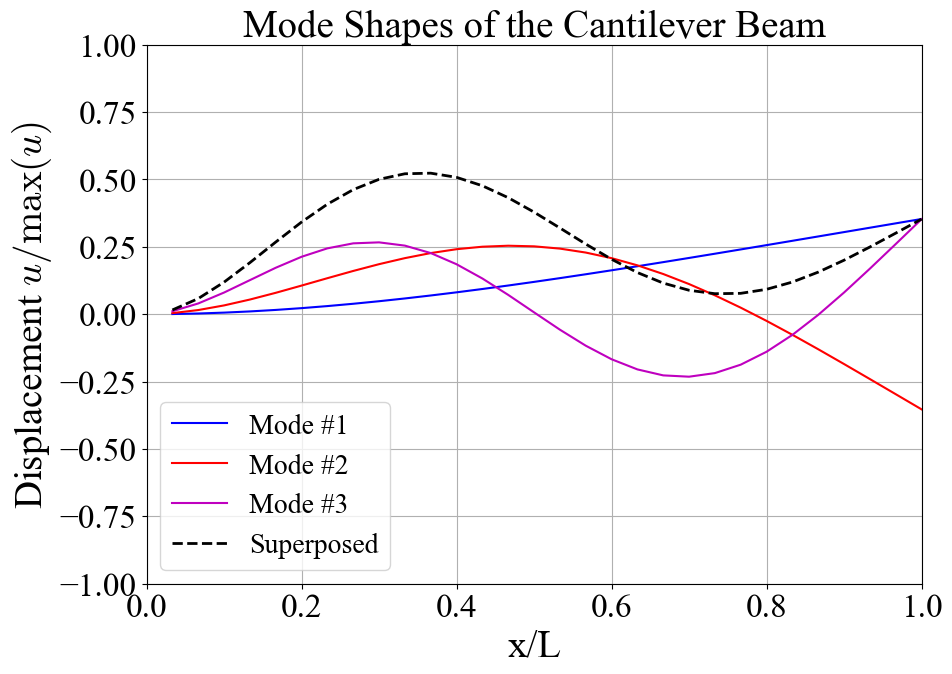

In [9]:
# Plot results
# mode_coord_test = mode_coord[10000,:]  # for plotting only
mode_coord_test = [1,1,1]
plt.figure(figsize=(10, 7))
plt.grid(True)
plt.plot(xl, Xnx[0, :], 'b-', linewidth=1.5, label='Mode #1')
plt.plot(xl, Xnx[1, :], 'r-', linewidth=1.5, label='Mode #2')
plt.plot(xl, Xnx[2, :], 'm-', linewidth=1.5, label='Mode #3')

# Superposed plot
superposed = mode_coord_test @ Xnx
plt.plot(xl, superposed, '--', color='black', linewidth=2, label='Superposed')

# Final plot formatting
plt.title('Mode Shapes of the Cantilever Beam')
plt.legend(loc='lower left',fontsize=20)
plt.xlabel('x/L')
plt.ylabel('Displacement $u/\max(u)$')
plt.ylim([-1,1])
plt.xlim([0,1])
plt.show()

# Clustering

In [ ]:
# AffinityPropagation Clustering
aff_matrix = np.abs(np.corrcoef(disp_all.T)) # Compute affinity matrix using correlation coefficient (n_candidates X n_points)
af = AffinityPropagation(damping=0.5,max_iter=10000, convergence_iter=10, copy=True, preference= 0.991, affinity='precomputed').fit(aff_matrix)
cluster_centers_indices = af.cluster_centers_indices_
labels = af.labels_
n_clusters_ = len(set(labels))
# sensors = cluster_centers_indices
print('n_clusters =',n_clusters_)

# fig = plt.figure(figsize=(8, 6))
# color_list = sns.color_palette(palette=cc.glasbey_category10,n_colors=n_clusters_)

# # Create scatter plots for all points
# plt.axvline(x=0, color='black', linestyle='--')
# plt.scatter(x_flatten, y_flatten, s=20, marker='o', c=[color_list[i] for i in labels])
# plt.scatter(x_flatten[cluster_centers_indices],y_flatten[cluster_centers_indices],marker='o', s=90, linewidths=2, color='black',facecolors='none')

# plt.ylim([0,45])
# plt.xlabel('$X^+$')
# plt.ylabel('$Y^+$')
# # plt.title('Clusters')
# #plt.savefig("clusters_map.png",format='png',bbox_inches='tight')
# plt.show()

n_clusters = 19


In [ ]:
## Save Data
# np.save('cluster_centers_indices.npy', cluster_centers_indices)
# np.save('labels.npy', labels)

# ## Load Data
cluster_centers_indices = np.load('cluster_centers_indices.npy')
labels = np.load('labels.npy')
n_clusters_ = len(set(labels))
print(n_clusters_)

19


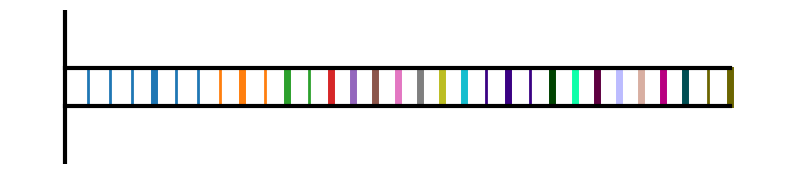

In [ ]:
# Generate schematic that combines CAAF sensors and clusters
L,n_candidate = 6,30
x_candidate = np.linspace(L/30, L, n_candidate)

# Plot arrows (loads) at x_list
color_list = sns.color_palette(palette=cc.glasbey_category10,n_colors=n_clusters_)

# Plot the beam
plt.figure(figsize=(10, 2))


# Fixed support (like a wall at x = 0)
plt.plot([0, 0], [-0.8, 0.8], 'k', linewidth=3)  # Thick vertical wall

for i in range(n_candidate):
  if i in cluster_centers_indices:
    plt.plot([x_candidate[i], x_candidate[i]], [-0.18, 0.18], linewidth=5, color = color_list[labels[i]])
  else:
    plt.plot([x_candidate[i], x_candidate[i]], [-0.2, 0.2], linewidth=2, color = color_list[labels[i]])

plt.plot([0, L], [0.2, 0.2], 'k-', linewidth=3)  # Beam (horizontal line)
plt.plot([0, L], [-0.2, -0.2], 'k-', linewidth=3)  # Beam (horizontal line)
# Formatting
plt.xlim(-0.5, L + 0.5)
plt.ylim(-0.8, 0.8)
plt.axis('off')
plt.savefig("SHM_clusters_AP.png",format='png',bbox_inches='tight')
plt.savefig("SHM_clusters_AP.eps",format='eps')
plt.show()

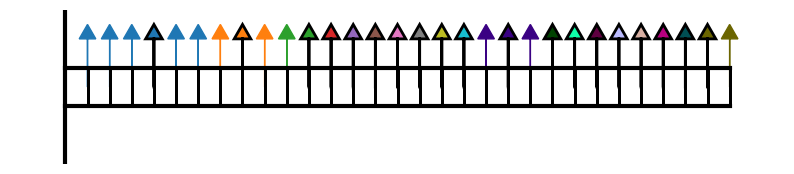

In [ ]:
L = 6
x_candidate = np.linspace(L/30, L, n_candidate)
# Plot the beam
plt.figure(figsize=(10, 2))
plt.plot([0, L], [0.2, 0.2], 'k-', linewidth=3)  # Beam (horizontal line)
plt.plot([0, L], [-0.2, -0.2], 'k-', linewidth=3)  # Beam (horizontal line)

# Fixed support (like a wall at x = 0)
plt.plot([0, 0], [-0.8, 0.8], 'k', linewidth=3)  # Thick vertical wall

# Plot arrows (loads) at x_list
color_list = sns.color_palette(palette=cc.glasbey_category10,n_colors=n_clusters_)

for i in range(n_candidate):
  # plt.scatter(x_candidate[i], 0, marker='x', s=100, color='black', linewidth=2)
  # print(color_list[labels[i]])
  if i in cluster_centers_indices:
    plt.arrow(x_candidate[i], 0.0, 0, 0.5, head_width=0.15, head_length=0.15, fc=color_list[labels[i]], ec='k',linewidth=2.0)
  else:
    plt.arrow(x_candidate[i], 0.0, 0, 0.5, head_width=0.15, head_length=0.15, fc=color_list[labels[i]], ec=color_list[labels[i]])
  # annotation = plt.annotate(str(rank), (x_candidate[i]-0.07, 0.7), fontsize=18, color='black')
  plt.plot([x_candidate, x_candidate], [-0.2, 0.2], 'k', linewidth=2)

# Formatting
plt.xlim(-0.5, L + 0.5)
plt.ylim(-0.8, 0.8)
plt.axis('off')
# plt.savefig("SHM_clusters.png",format='png',bbox_inches='tight')
# plt.savefig("SHM_clusters.eps",format='eps')
plt.show()

## Clustering sensitivity test

In [ ]:
# Compute affinity matrix (same as your original code)
aff_matrix = np.abs(np.corrcoef(disp_all.T))

# Spectral Clustering
# Note: You must specify the number of clusters you want
sc = SpectralClustering(n_clusters=19, affinity='precomputed', random_state=42)
labels = sc.fit_predict(aff_matrix)

n_clusters_ = len(set(labels))
print('n_clusters =', n_clusters_)

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


n_clusters = 19


In [ ]:
from sklearn.cluster import AgglomerativeClustering

# Compute distance matrix
dist_matrix = 1.0 - np.abs(np.corrcoef(disp_all.T))
np.fill_diagonal(dist_matrix, 0)

# Agglomerative Clustering
# distance_threshold determines how distinct clusters must be to stay separate
agg = AgglomerativeClustering(n_clusters=None, distance_threshold=0.01,
                              metric='precomputed', linkage='average')
labels = agg.fit_predict(dist_matrix)

n_clusters_ = len(set(labels))
print('n_clusters =', n_clusters_)

n_clusters = 19


In [ ]:
from sklearn.cluster import DBSCAN

# Compute distance matrix
dist_matrix = 1.0 - np.abs(np.corrcoef(disp_all.T))
np.fill_diagonal(dist_matrix, 0)

# DBSCAN
# eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other.
# min_samples: The number of samples in a neighborhood for a point to be considered as a core point.
db = DBSCAN(eps=0.006, min_samples=1, metric='precomputed')
labels = db.fit_predict(dist_matrix)

# Ignore noise (-1) when counting actual clusters
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
print('n_clusters =', n_clusters_)
print('Noise points =', list(labels).count(-1))

n_clusters = 19
Noise points = 0


In [ ]:
from sklearn.cluster import SpectralClustering
import os
# Set the environment variable to avoid the MKL memory leak
os.environ["OMP_NUM_THREADS"] = "1"

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances_argmin
# Fit the model
kmeans = KMeans(n_clusters=19, n_init='auto').fit(disp_all.T)

synthetic_centers = kmeans.cluster_centers_
cluster_centers_indices = pairwise_distances_argmin(synthetic_centers, disp_all.T)

print("Closest actual data point indices:", cluster_centers_indices)
labels = kmeans.labels_
n_clusters_ = len(set(labels))
print('n_clusters =', n_clusters_)

Closest actual data point indices: [ 4 23 29 18 14 11 26  1  8 28 27 21 15 25 13  6 24 22 12]
n_clusters = 19


D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


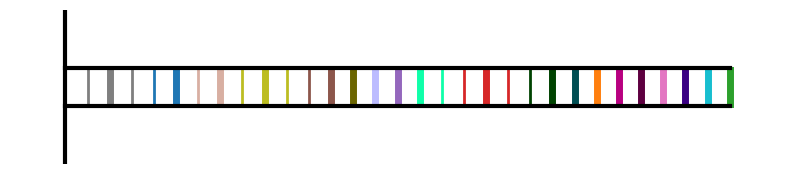

In [ ]:
# Generate schematic that combines CAAF sensors and clusters
L,n_candidate = 6,30
x_candidate = np.linspace(L/30, L, n_candidate)

# Plot arrows (loads) at x_list
color_list = sns.color_palette(palette=cc.glasbey_category10,n_colors=n_clusters_)

# Plot the beam
plt.figure(figsize=(10, 2))


# Fixed support (like a wall at x = 0)
plt.plot([0, 0], [-0.8, 0.8], 'k', linewidth=3)  # Thick vertical wall

for i in range(n_candidate):
  if i in cluster_centers_indices:
    plt.plot([x_candidate[i], x_candidate[i]], [-0.18, 0.18], linewidth=5, color = color_list[labels[i]])
  else:
    plt.plot([x_candidate[i], x_candidate[i]], [-0.2, 0.2], linewidth=2, color = color_list[labels[i]])

plt.plot([0, L], [0.2, 0.2], 'k-', linewidth=3)  # Beam (horizontal line)
plt.plot([0, L], [-0.2, -0.2], 'k-', linewidth=3)  # Beam (horizontal line)
# Formatting
plt.xlim(-0.5, L + 0.5)
plt.ylim(-0.8, 0.8)
plt.axis('off')
# plt.savefig("SHM_clusters_DBSCAN.png",format='png',bbox_inches='tight')
# plt.savefig("SHM_clusters_DBSCAN.eps",format='eps')
plt.show()

# Average Model Training and Attribution

Using GPU
Starting run 0
Train Epoch: 1/100  Train Loss: 2.2600e-01, Test Loss: 9.9802e-02, Learning Rate = 1.00e-05
Train Epoch: 11/100  Train Loss: 1.6651e-02, Test Loss: 4.2132e-03, Learning Rate = 1.00e-05
Train Epoch: 21/100  Train Loss: 1.5167e-02, Test Loss: 3.4927e-03, Learning Rate = 1.00e-05
Train Epoch: 31/100  Train Loss: 1.4483e-02, Test Loss: 2.7907e-03, Learning Rate = 5.00e-06
Train Epoch: 41/100  Train Loss: 1.4305e-02, Test Loss: 2.4367e-03, Learning Rate = 2.50e-06
Train Epoch: 51/100  Train Loss: 1.3850e-02, Test Loss: 2.7735e-03, Learning Rate = 1.25e-06
Train Epoch: 61/100  Train Loss: 1.3789e-02, Test Loss: 2.3913e-03, Learning Rate = 6.25e-07
Train Epoch: 71/100  Train Loss: 1.4260e-02, Test Loss: 3.3769e-03, Learning Rate = 3.13e-07
Train Epoch: 81/100  Train Loss: 1.4454e-02, Test Loss: 5.3719e-03, Learning Rate = 3.13e-07
Train Epoch: 91/100  Train Loss: 1.4235e-02, Test Loss: 4.6508e-03, Learning Rate = 1.56e-07


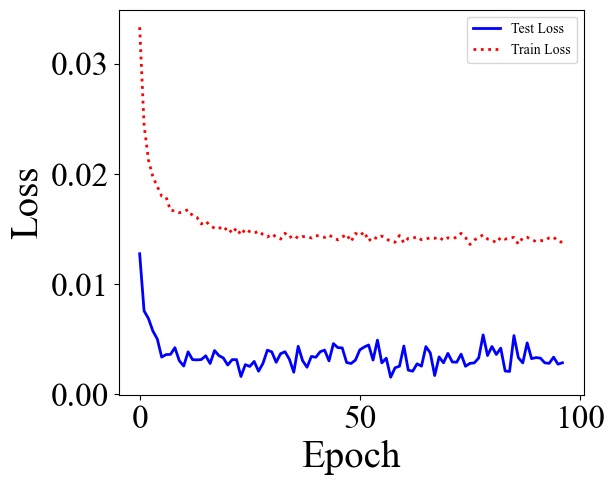

Starting run 1
Train Epoch: 1/100  Train Loss: 2.0065e-01, Test Loss: 8.5254e-02, Learning Rate = 1.00e-05
Train Epoch: 11/100  Train Loss: 1.8010e-02, Test Loss: 4.4706e-03, Learning Rate = 1.00e-05
Train Epoch: 21/100  Train Loss: 1.5300e-02, Test Loss: 4.5953e-03, Learning Rate = 1.00e-05
Train Epoch: 31/100  Train Loss: 1.4776e-02, Test Loss: 5.8064e-03, Learning Rate = 5.00e-06
Train Epoch: 41/100  Train Loss: 1.3638e-02, Test Loss: 4.1279e-03, Learning Rate = 5.00e-06
Train Epoch: 51/100  Train Loss: 1.3609e-02, Test Loss: 4.2617e-03, Learning Rate = 2.50e-06
Train Epoch: 61/100  Train Loss: 1.3097e-02, Test Loss: 4.2147e-03, Learning Rate = 1.25e-06
Train Epoch: 71/100  Train Loss: 1.3432e-02, Test Loss: 4.3424e-03, Learning Rate = 6.25e-07
Train Epoch: 81/100  Train Loss: 1.3186e-02, Test Loss: 3.2659e-03, Learning Rate = 3.13e-07
Train Epoch: 91/100  Train Loss: 1.3085e-02, Test Loss: 5.3948e-03, Learning Rate = 3.13e-07


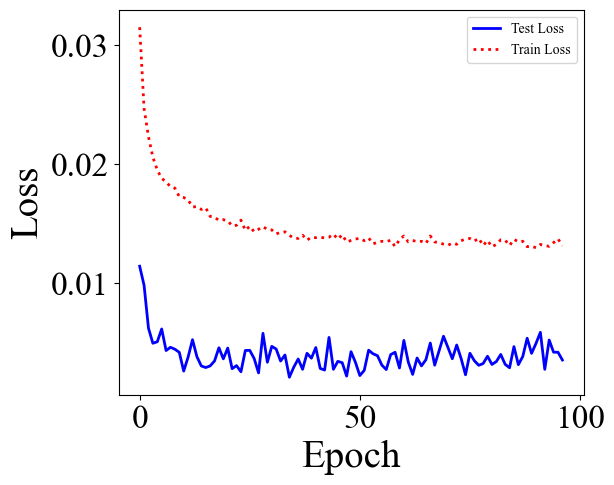

Starting run 2
Train Epoch: 1/100  Train Loss: 2.9095e-01, Test Loss: 1.2375e-01, Learning Rate = 1.00e-05
Train Epoch: 11/100  Train Loss: 1.7053e-02, Test Loss: 2.9377e-03, Learning Rate = 1.00e-05
Train Epoch: 21/100  Train Loss: 1.5388e-02, Test Loss: 3.7892e-03, Learning Rate = 1.00e-05
Train Epoch: 31/100  Train Loss: 1.4156e-02, Test Loss: 5.5165e-03, Learning Rate = 1.00e-05
Train Epoch: 41/100  Train Loss: 1.3520e-02, Test Loss: 3.1382e-03, Learning Rate = 5.00e-06
Train Epoch: 51/100  Train Loss: 1.3418e-02, Test Loss: 2.8823e-03, Learning Rate = 2.50e-06
Train Epoch: 61/100  Train Loss: 1.2780e-02, Test Loss: 2.4677e-03, Learning Rate = 1.25e-06
Train Epoch: 71/100  Train Loss: 1.3072e-02, Test Loss: 4.1674e-03, Learning Rate = 6.25e-07
Train Epoch: 81/100  Train Loss: 1.2781e-02, Test Loss: 3.2579e-03, Learning Rate = 6.25e-07
Train Epoch: 91/100  Train Loss: 1.2854e-02, Test Loss: 3.6383e-03, Learning Rate = 3.13e-07


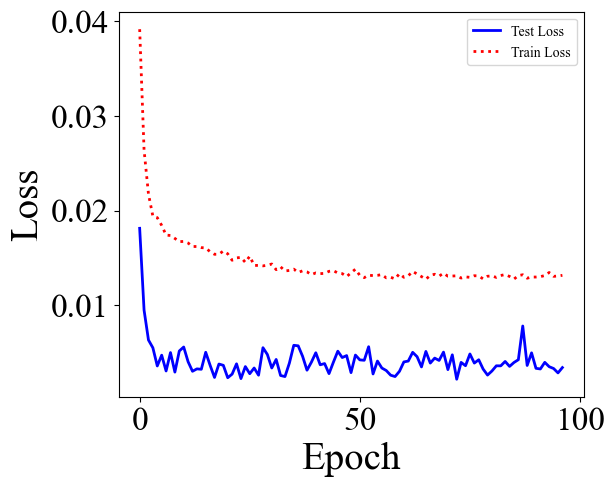

Starting run 3
Train Epoch: 1/100  Train Loss: 3.7901e-01, Test Loss: 1.6518e-01, Learning Rate = 1.00e-05
Train Epoch: 11/100  Train Loss: 1.7419e-02, Test Loss: 4.3005e-03, Learning Rate = 1.00e-05
Train Epoch: 21/100  Train Loss: 1.5233e-02, Test Loss: 2.7650e-03, Learning Rate = 1.00e-05
Train Epoch: 31/100  Train Loss: 1.4229e-02, Test Loss: 2.8462e-03, Learning Rate = 1.00e-05
Train Epoch: 41/100  Train Loss: 1.4060e-02, Test Loss: 3.9098e-03, Learning Rate = 5.00e-06
Train Epoch: 51/100  Train Loss: 1.3338e-02, Test Loss: 3.1811e-03, Learning Rate = 5.00e-06
Train Epoch: 61/100  Train Loss: 1.3369e-02, Test Loss: 4.0591e-03, Learning Rate = 2.50e-06
Train Epoch: 71/100  Train Loss: 1.3200e-02, Test Loss: 5.2401e-03, Learning Rate = 1.25e-06
Train Epoch: 81/100  Train Loss: 1.3242e-02, Test Loss: 2.6058e-03, Learning Rate = 6.25e-07
Train Epoch: 91/100  Train Loss: 1.3087e-02, Test Loss: 3.9155e-03, Learning Rate = 3.13e-07


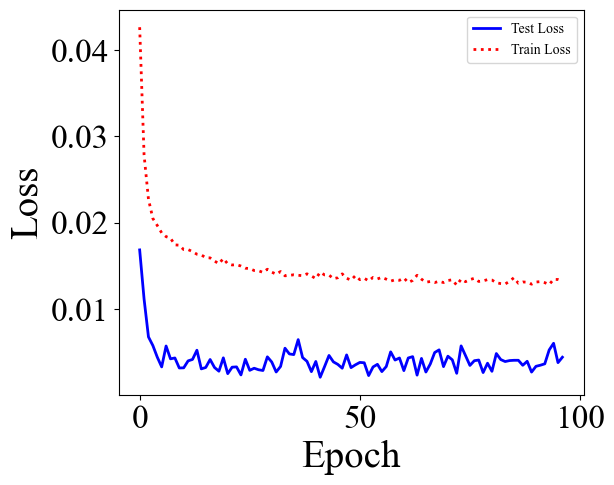

Starting run 4
Train Epoch: 1/100  Train Loss: 3.2759e-01, Test Loss: 1.6299e-01, Learning Rate = 1.00e-05
Train Epoch: 11/100  Train Loss: 1.7340e-02, Test Loss: 3.7934e-03, Learning Rate = 1.00e-05
Train Epoch: 21/100  Train Loss: 1.5597e-02, Test Loss: 4.5575e-03, Learning Rate = 1.00e-05
Train Epoch: 31/100  Train Loss: 1.3907e-02, Test Loss: 4.3189e-03, Learning Rate = 5.00e-06
Train Epoch: 41/100  Train Loss: 1.3729e-02, Test Loss: 2.8347e-03, Learning Rate = 2.50e-06
Train Epoch: 51/100  Train Loss: 1.3749e-02, Test Loss: 3.6228e-03, Learning Rate = 1.25e-06
Train Epoch: 61/100  Train Loss: 1.3534e-02, Test Loss: 4.2520e-03, Learning Rate = 6.25e-07
Train Epoch: 71/100  Train Loss: 1.3625e-02, Test Loss: 3.9257e-03, Learning Rate = 6.25e-07
Train Epoch: 81/100  Train Loss: 1.3212e-02, Test Loss: 3.2773e-03, Learning Rate = 3.13e-07
Train Epoch: 91/100  Train Loss: 1.3610e-02, Test Loss: 4.1044e-03, Learning Rate = 1.56e-07


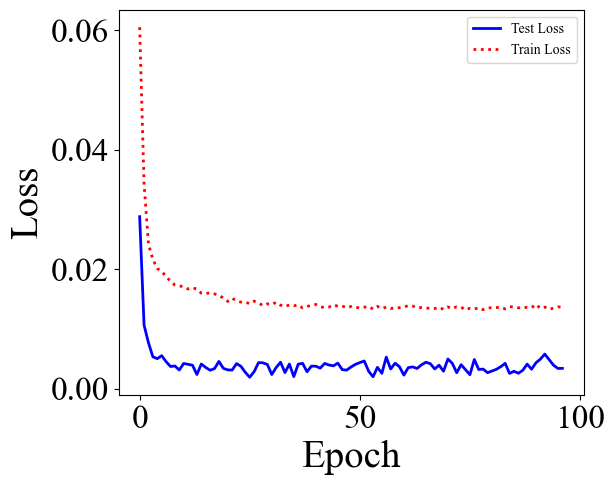

19 attribution sensors: 29,28,27,10,20,26,14,18,24,25,21,12,16,7,15,22,23,4,1
RMS = 0.1470724
CN = 1.7348
DET = 2644547.5


In [ ]:
# SET Testing Sensors HERE

n_iter = 5
n_sensors = 5
test_split = 0.1
# sensors = np.arange(n_candidate)
# sensors = cluster_centers_indices
# sensors = np.array([25,9,29,27,11,24,21,13,17,23,12,19,14,16,7])  # CAAF
sensors = np.array([29,28,27,10,20,26,14,18,24,25,21,12,16,7,15,22,23,4,1]) # CAAF Kmeans clustering
# sensors = np.array([29 ,28, 27, 26,  9 ,19 ,20 , 8, 10, 18, 21, 25 ,11 ,17  ,7])  # KE
# sensors = [ 0,1, 9,11, 12, 13 ,15 ,16, 18, 20 ,22, 24 ,25, 26, 28]      # RMS
# sensors =  [ 0,  2,  8 , 9, 10, 11, 13 ,16, 17, 20 ,21, 22, 24 ,27, 28] # CN
# sensors = [ 8 , 9, 10, 11, 12, 17, 18, 19, 20, 21, 22, 26, 27, 28, 29]  # DET (EI)
# sensors = [7,  8,  9 ,10, 12, 13, 14, 18 ,19, 20 ,21, 22 ,26, 27, 28]   # combined

# sensors = [25,9,29,27,11] # CAAF
# sensors = [29,28, 27, 26,  9] # KE
# sensors = [10, 12, 18, 22, 27] # RMS
# sensors = [10, 11, 18, 21, 27] # CN
# sensors = [ 9 ,10, 19, 20 ,29] # DET
# sensors = [ 9, 12, 18, 22, 27] # Combined
mode = 'test'
# mode = 'attr'

# random_states = np.random.randint(0, 201, 10)
# random_states =  [71,  43,  95, 115, 200 ,137,  85, 186,   5, 111]
# random_states =  [ 99,  94, 120, 101 ,112, 109 , 95, 186 , 44, 151]
random_states = [147,81,37,132,101]
# random_states = [130,29, 67,60,30]

use_gpu = True # Switch to enable GPU training

if use_gpu and torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using GPU")
else:
    device = torch.device("cpu")
    print("Using CPU")

#-------------------------------------------------------------------------------
best_error = 0.01
errors = np.zeros([n_iter,1])
weights_mean_all = np.zeros([n_iter,len(sensors)])
for iter in range(n_iter):
  print('Starting run', iter)
  random_state = random_states[iter]
  X_train, X_test, y_train, y_test = train_test_split(
      disp_scaled[:,sensors],
      mode_coord,
      test_size=test_split,
      shuffle=True,
      random_state=random_states[iter]
  )

  # make datasets and dataloaders
  train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
  test_dataset = TensorDataset(torch.tensor(X_test), torch.tensor(y_test))

  # set random seed
  torch.manual_seed(random_state)
  train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
  test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)


  # Model for attribution with candidate sensors (>17 sensors)
  # layer_size = 8
  # model = nn.Sequential(
  #       nn.Flatten(),
  #       nn.Linear(len(sensors), layer_size,bias=False),
  #       nn.BatchNorm1d(layer_size),
  #       nn.LeakyReLU(),
  #       nn.Linear(layer_size, layer_size,bias=False),
  #       nn.BatchNorm1d(layer_size),
  #       nn.LeakyReLU(),
  #       nn.Linear(layer_size, layer_size,bias=False),
  #       nn.BatchNorm1d(layer_size),
  #       nn.LeakyReLU(),
  #       nn.Linear(layer_size, 3,bias=False),
  # )

  layer_size = 32
  model = nn.Sequential(
        nn.Flatten(),
        nn.Linear(len(sensors), layer_size,bias=True),
        nn.BatchNorm1d(layer_size),
        nn.ReLU(),
        nn.Linear(layer_size, layer_size,bias=True),
        nn.BatchNorm1d(layer_size),
        nn.ReLU(),
        nn.Linear(layer_size, layer_size,bias=True),
        nn.BatchNorm1d(layer_size),
        nn.ReLU(),
        nn.Linear(layer_size, 3,bias=False),
  )

  model = model.to(torch.double).to(device)
  # print(model)

  optimizer = torch.optim.Adam(model.parameters(), lr=0.00001, weight_decay=1e-2)
  scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, min_lr=1e-7, eps=1e-7, patience=10)
  loss_fn = nn.MSELoss()
  # n_epochs = 20
  threshold = 1e-5   # early stopping threshold for test loss
  n_epochs_min = 30
  n_epochs_max = 50
  min_loss = 1.0
  print_interval = 10

  # store metrics
  training_loss_history = np.zeros([n_epochs_max, 1])
  validation_loss_history = np.zeros([n_epochs_max, 1])

  for epoch in range(n_epochs_max):
      model.train()
      for batch_idx, (data, target) in enumerate(train_loader):
          # target = target.unsqueeze(1)
          # Erase accumulated gradients
          optimizer.zero_grad()

          data, target = data.to(device), target.to(device)

          # Forward pass
          # data = torch.squeeze(data)
          output = model(data)

          # Calculate loss
          loss = loss_fn(output, target)

          # Backward pass
          loss.backward()

          # Weight update
          optimizer.step()

          training_loss_history[epoch] += loss.item()

      # Track loss each epoch
      training_loss_history[epoch] /= len(train_loader)
      if epoch % print_interval == 0:
        print(f'Train Epoch: %d/%i  Train Loss: %1.4e' % (epoch + 1, n_epochs_max, training_loss_history[epoch,0]),end='')


      # Turning off automatic differentiation
      with torch.no_grad():
          model.eval()
          for data, target in test_loader:
              # target = target.unsqueeze(1)
              data, target = data.to(device), target.to(device)
              output = model(data)
              validation_loss_history[epoch] += loss_fn(output, target).item()  # Sum up batch loss

          validation_loss_history[epoch] /= len(test_loader)
          if epoch % print_interval == 0:
            print(f', Test Loss: %1.4e' % validation_loss_history[epoch,0],end='')

      # loss_rate = (validation_loss_history[epoch-1]-validation_loss_history[epoch])/validation_loss_history[epoch]
      # loss_rate = (training_loss_history[epoch-1]-training_loss_history[epoch])/training_loss_history[epoch]
      # if epoch > n_epochs_min and loss_rate < threshold and loss_rate > 0: #loss_rate > 0 and
      #   break
      # if epoch > n_epochs_min:
      #   if validation_loss_history[epoch] < min_loss:
      #     break
      # else:
      #     if validation_loss_history[epoch] < min_loss:
      #       min_loss = validation_loss_history[epoch]

      scheduler.step(validation_loss_history[epoch,0]) # adjust learning rate
      if epoch % print_interval == 0:
        print(f', Learning Rate = %1.2e' % optimizer.param_groups[0]['lr'])

  plt.rcParams['figure.figsize'] = [6, 5] # change figure size
  plt.plot(validation_loss_history[2:epoch], color='b',linewidth=2, label='Test Loss')
  plt.plot(training_loss_history[2:epoch],':',color='r',linewidth=2, label='Train Loss')
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()

  if validation_loss_history[epoch] < best_error:
    best_error = validation_loss_history[epoch]
    best_model = model

  if mode == 'test':
    with torch.no_grad():
      test_output = model(torch.tensor(X_test).to(device)).cpu().detach().numpy()

    # print(test_output.shape)
    # unscale test_output
    # compute L2 error

    errors[iter,0] = np.linalg.norm(test_output - y_test,2)/np.linalg.norm(y_test - np.mean(y_test),2) # L2 error norm
    # print('L2 errors =', errors)
  else:
    # Find most important sensors
    ig = captum.attr.IntegratedGradients(model)
    # randomly select 10000 indices from 1 to n_sample^3
    samplei = random.sample(range(N_sample), 20000)
    disp_temp = disp_scaled[samplei,:]
    test_shap = torch.tensor(disp_temp[:,sensors]).to(device)
    test_shap.requires_grad_()
    # attr = ig.attribute(test_shap,target=0,n_steps=50)
    # attr = attr.cpu().detach().numpy()
    # weights_mean_all[iter,:] = np.mean(abs(attr),axis=0) # average over time samples (1st axis)

    # Store the averaged attributions for each target and loop over all 3 output entries (targets 0, 1, 2)
    target_attrs = []
    for target_idx in range(3):
        attr = ig.attribute(test_shap, target=target_idx, n_steps=50)
        attr = attr.cpu().detach().numpy()
        target_attrs.append(np.mean(abs(attr), axis=0))
    weights_mean_all[iter,:] = np.mean(target_attrs, axis=0)

if mode == 'test':
  # print('L2 errors =', errors)
  print('L2 errors =',"["+','.join(map(str,np.round(errors.flatten(),6)))+"]")
  print('Average L2 error =', np.mean(errors))
else:
  weights_mean = np.mean(weights_mean_all,axis=0) # average over iterations
  sensor_temp = np.flip(np.argsort(weights_mean))
  attr_sensors = np.array(sensors)[sensor_temp[:n_sensors]] # Indices of the attribution sensor locations
  sensors_str = ','.join(map(str, attr_sensors)) #print "sensors" array as string and add commas
  print(str(n_sensors)+" attribution sensors:",sensors_str)
  results = process_modes(Xnx, attr_sensors[:15], verbose = True)

In [ ]:
# Attribution step
ig = captum.attr.IntegratedGradients(model)
# randomly select 10000 indices from 1 to n_sample^3
samplei = random.sample(range(N_sample), 20000)
disp_temp = disp_scaled[samplei,:]
test_shap = torch.tensor(disp_temp[:,sensors]).to(device)
test_shap.requires_grad_()
# attr = ig.attribute(test_shap,target=0,n_steps=50)
# attr = attr.cpu().detach().numpy()
# weights_mean_all[iter,:] = np.mean(abs(attr),axis=0) # average over time samples (1st axis)

# Store the averaged attributions for each target and loop over all 3 output entries (targets 0, 1, 2)
target_attrs = []
for target_idx in range(3):
    attr = ig.attribute(test_shap, target=target_idx, n_steps=50)
    attr = attr.cpu().detach().numpy()
    target_attrs.append(np.mean(abs(attr), axis=0))
weights_mean_all[iter,:] = np.mean(target_attrs, axis=0)

weights_mean = np.mean(weights_mean_all,axis=0) # average over iterations
sensor_temp = np.flip(np.argsort(weights_mean))
attr_sensors = np.array(sensors)[sensor_temp[:n_sensors]] # Indices of the attribution sensor locations
sensors_str = ','.join(map(str, attr_sensors)) #print "sensors" array as string and add commas
print(str(n_sensors)+" attribution sensors:",sensors_str)
results = process_modes(Xnx, attr_sensors[:15], verbose = True)

19 attribution sensors: 27,28,29,26,24,18,20,21,25,14,12,16,23,10,7,22,15,4,1
RMS = 0.173582
CN = 1.7587
DET = 2627562.7


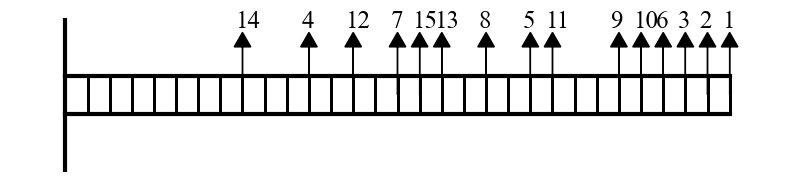

RMS = 0.1470724
CN = 1.7348
DET = 2644547.5


In [ ]:
plot_cantilever_sensors(6,30, attr_sensors[:15])
results = process_modes(Xnx, attr_sensors[:15], verbose = True)

In [40]:
errors_CAAF = [0.180115,0.170521,0.14346,0.149935,0.128839,0.153887,0.09922,0.17447,0.173142,0.152087] # CAAF Errors
errors_KE = [0.170553,0.174127,0.190859,0.1622,0.147596, 0.15967,0.106754,0.17471,0.157088,0.173114] # KE
errors_RMS = [0.168176,0.17933,0.162759,0.165834,0.15179,0.151637,0.098325,0.187588,0.173135,0.153076]
errors_CN = [0.170364,0.177898,0.157684,0.168437,0.151769,0.151117,0.106135,0.182105,0.159747,0.159298]
errors_DET = [0.168999,0.165029,0.162975,0.152461,0.178425,0.154855,0.102352,0.168658,0.174054,0.164628]
errors_combined = [0.163068,0.175501,0.165604,0.166742,0.14918,0.153887,0.09922,0.17447,0.173142,0.152087]

# data = {
#     'CAAF': errors_CAAF,
#     'KE': errors_KE,
#     'Min RMS': errors_RMS,
#     'Min CN': errors_CN,
#     'EI (Max DET)': errors_DET,
#     'Combined Score': errors_combined
# }
# df = pd.DataFrame(data)
# df.to_csv('SHM_pred_errors_6configs.csv', index=False)

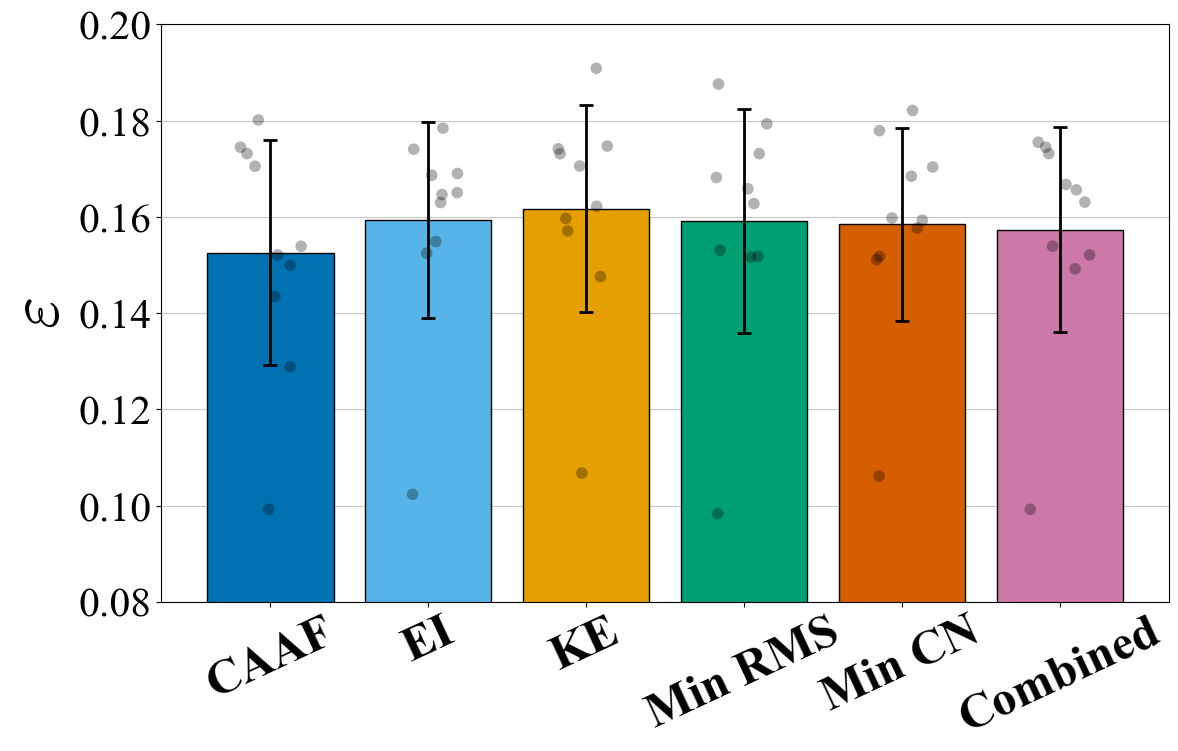

In [38]:
methods = ['CAAF', 'EI', 'KE', 'Min RMS', 'Min CN',  'Combined']
all_errors = [errors_CAAF, errors_DET, errors_KE, errors_RMS, errors_CN, errors_combined]

# colors = np.array([
#     [0.121569, 0.466667, 0.705882], # Python Blue
#     [0.839216, 0.152941, 0.156863], # Python Red
#     [0.172549, 0.627451, 0.172549], # Green
#     [1.000000, 0.498039, 0.054902], # Orange
#     [0.090196, 0.745098, 0.811765]  # Teal
# ])
colors=['#0072B2', '#56B4E9', '#E69F00', '#009E73', '#D55E00', '#CC79A7']

means = [np.mean(e) for e in all_errors]
stds = [np.std(e) for e in all_errors]

plt.figure(figsize=(13, 7.5))
plt.gca().set_axisbelow(True)
plt.grid(axis='y', linestyle='-', alpha=0.7)

# bars = plt.bar(methods, means, yerr=stds, capsize=5, color=['blue', 'red', 'green', 'm', 'cyan', 'y'], alpha=1.0)
bars = plt.bar(methods, means, yerr=stds, capsize=5, width=0.8,
              #  color=[colors[0], colors[1], colors[2], 'm', colors[4], 'y'], alpha=1.0,
               color=colors, alpha=1.0,
               edgecolor='black',       # Adds a black outline to the bars
               linewidth=1,           # Controls the thickness of the bar outline
               error_kw={'elinewidth': 2, 'markeredgewidth': 2}) # Controls error bar thickness

sz = 70              # Dot size
alpha_val = 0.3      # Transparency (0.0 to 1.0)
jitter_width = 0.4  # Spread of dots across the bar's width
# ------------------------

# --- Scatter Plot Overlay Loop ---
for bar, raw_data in zip(bars, all_errors):
    # Convert to numpy array and drop NaNs just in case
    raw_data = np.array(raw_data)
    raw_data = raw_data[~np.isnan(raw_data)]

    # Calculate the exact center X coordinate of the current bar
    x_center = bar.get_x() + bar.get_width() / 2.0

    # Generate random horizontal jitter around the center
    x_jitter = x_center + (np.random.rand(len(raw_data)) - 0.5) * jitter_width

    # Plot the dots (zorder=3 ensures they sit on top of the bars)
    plt.scatter(x_jitter, raw_data, s=sz, color='k', alpha=alpha_val,
                edgecolors='none', zorder=3)

plt.ylabel('$\\varepsilon$',fontsize=50)

# # Add text labels on bars
# for bar, mean, std in zip(bars, means, stds):
#     height = bar.get_height()
#     plt.text(bar.get_x() + bar.get_width()/2., height + 0.005,
#              f'{mean:.4f} ± {std:.4f}',
#              ha='center', va='bottom', fontsize=14)

plt.xticks(fontsize=35, fontweight='bold',rotation=25)

plt.yticks([0.08,0.1,0.12,0.14,0.16,0.18,0.2])
plt.ylim(0.08, 0.2)
# plt.savefig('SHM_barchart.pdf',format = 'pdf')
# plt.savefig('SHM_barchart.png')
plt.show()

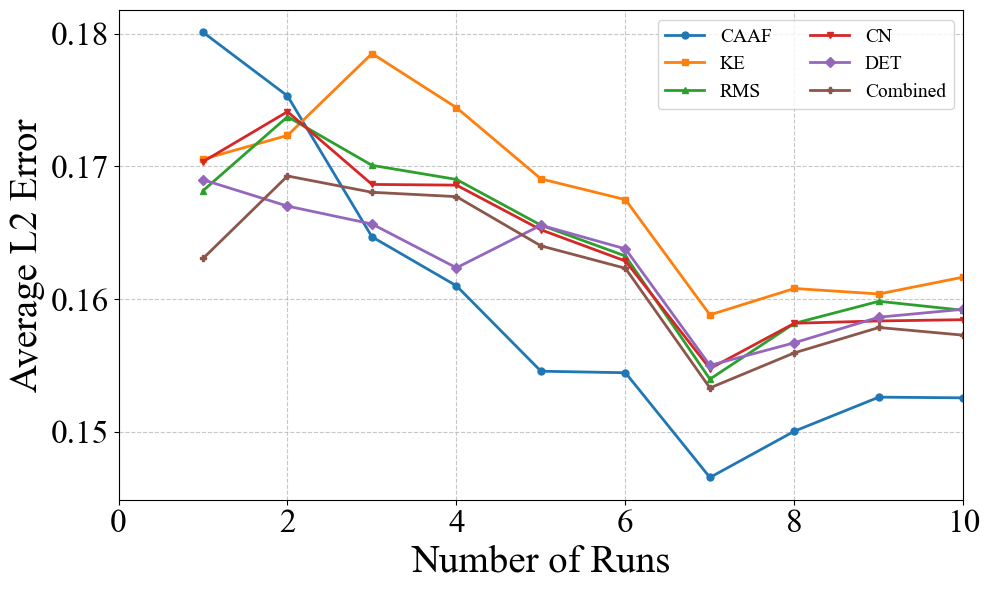

In [ ]:
plt.figure(figsize=(10, 6))

# Define markers for distinction
markers = ['o', 's', '^', 'v', 'D', 'P']

for i, errors in enumerate(all_errors):
    # Convert to numpy array for vectorized operations
    errors_np = np.array(errors)

    # Calculate running average
    iterations = np.arange(1, len(errors_np) + 1)
    running_avg = np.cumsum(errors_np) / iterations

    # Plot
    plt.plot(iterations, running_avg, label=methods[i], linewidth=2, marker=markers[i], markersize=5)

plt.xlabel('Number of Runs')
plt.ylabel('Average L2 Error')
# plt.title('Convergence of Running Average L2 Error')
plt.legend(ncol=2, fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim([1, len(all_errors[0])])
plt.xticks(np.arange(0, len(all_errors[0])+1, 2))
plt.tight_layout()
plt.show()

# Plotting

In [ ]:
# attr_sensors = [29,7,24,27,16,13,12,23,26,5,18,19,10,20,22] # 15 attr sensors, 30 candidates
attr_sensors = [25,9,29,27,11,24,21,13,17,23,12,19,14,16,7,22,15,26,3] # 19 attr sensors, 19 candidates, 30k IG points (CAAF FINAL)
# attr_sensors = np.array([25,9,29,27,11,24,21,13,17,23,12,19,14,16,7])  # CAAF
# attr_sensors = np.array([29,28,27,10,20,26,14,18,24,25,21,12,16,7,15,22,23,4,1]) # Kmeans cluster, 19 candidates

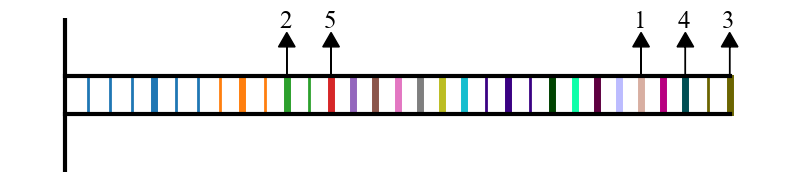

In [ ]:
# Generate schematic that combines CAAF sensors and clusters
cluster_centers_indices = attr_sensors
L,n_candidate, sensors = 6,30, attr_sensors[:5]
x_candidate = np.linspace(L/30, L, n_candidate)

# Plot arrows (loads) at x_list
color_list = sns.color_palette(palette=cc.glasbey_category10,n_colors=len(cluster_centers_indices))

# Plot the beam
plt.figure(figsize=(10, 2))


# Fixed support (like a wall at x = 0)
plt.plot([0, 0], [-0.8, 0.8], 'k', linewidth=3)  # Thick vertical wall

# Plot arrows (loads) at x_list
rank = 1
for i in sensors:
  # plt.scatter(x_candidate[i], 0, marker='x', s=100, color='black', linewidth=2)
  plt.arrow(x_candidate[i], 0.0, 0, 0.5, head_width=0.15, head_length=0.15, fc='k', ec='k')
  annotation = plt.annotate(str(rank), (x_candidate[i]-0.07, 0.7), fontsize=18, color='black')
  rank += 1

for i in range(n_candidate):
  if i in cluster_centers_indices:
    plt.plot([x_candidate[i], x_candidate[i]], [-0.18, 0.18], linewidth=5, color = color_list[labels[i]])
  else:
    plt.plot([x_candidate[i], x_candidate[i]], [-0.2, 0.2], linewidth=2, color = color_list[labels[i]])

plt.plot([0, L], [0.2, 0.2], 'k-', linewidth=3)  # Beam (horizontal line)
plt.plot([0, L], [-0.2, -0.2], 'k-', linewidth=3)  # Beam (horizontal line)
# Formatting
plt.xlim(-0.5, L + 0.5)
plt.ylim(-0.8, 0.8)
plt.axis('off')
plt.savefig("SHM_CAAF&clusters_5.png",format='png',bbox_inches='tight')
plt.savefig("SHM_CAAF&clusters_5.eps",format='eps')
plt.show()

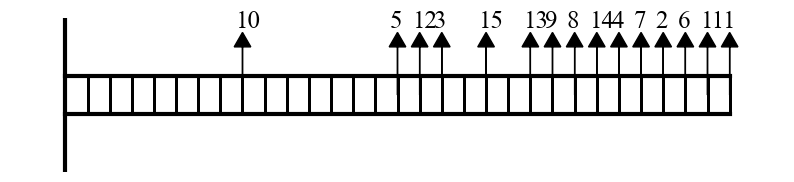

RMS = 0.2158422
CN = 2.3925
DET = 1767726.0


In [ ]:
plot_cantilever_sensors(6,30, attr_sensors[:15])
results = process_modes(Xnx, attr_sensors[:15], verbose = True)

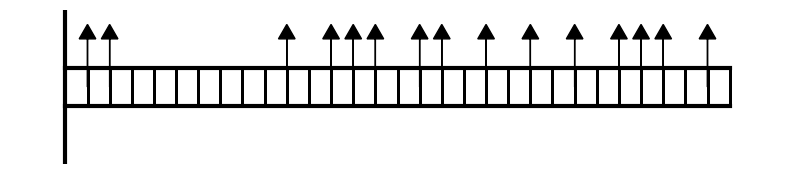

RMS = 1.8965892869764351e-07
CN = 1.2844172226269683
DET = 1252006.0717914342


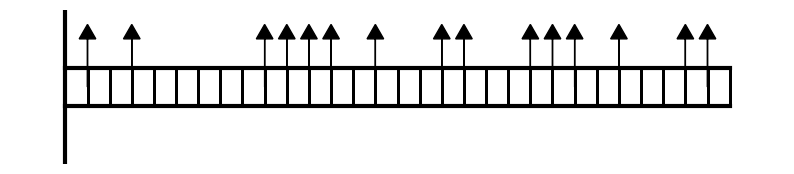

RMS = 0.0007127263535301999
CN = 1.0036572042214198
DET = 1655876.3966787453


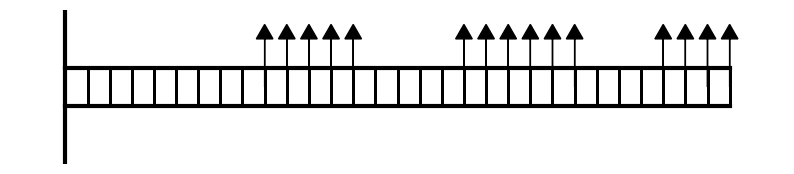

RMS = 0.025297815607882957
CN = 1.3912213656316827
DET = 3648956.2370236237


In [ ]:
opt_RMS = [ 0,1,9, 11, 12, 13, 15 ,16 ,18, 20 ,22, 24, 25, 26, 28]
opt_CN = [ 0 , 2,  8  ,9, 10, 11, 13, 16, 17, 20 ,21, 22, 24, 27 ,28]
opt_DET =  [ 8,  9, 10, 11, 12, 17 ,18, 19, 20, 21, 22, 26, 27, 28 ,29]

plot_cantilever_sensors(6,30, opt_RMS, show_rank=False, save_fig = True, save_name = "SHM_opt_RMS")
results = process_modes(Xnx, opt_RMS, verbose = True)

plot_cantilever_sensors(6,30, opt_CN, show_rank=False, save_fig = True, save_name = "SHM_opt_CN")
results = process_modes(Xnx, opt_CN, verbose = True)

plot_cantilever_sensors(6,30, opt_DET, show_rank=False, save_fig = True, save_name = "SHM_opt_DET")
results = process_modes(Xnx, opt_DET, verbose = True)

In [ ]:
min_RMS_sensors = np.load('min_RMS_sensors.npy', allow_pickle=True)
min_CN_sensors = np.load('min_CN_sensors.npy', allow_pickle=True)
combined_sensors = np.load('combined_sensors.npy', allow_pickle=True)
min_RMS_metrics = np.load('min_RMS_metrics.npy', allow_pickle=True)
min_CN_metrics = np.load('min_CN_metrics.npy', allow_pickle=True)
combined_metrics = np.load('combined_metrics.npy', allow_pickle=True)

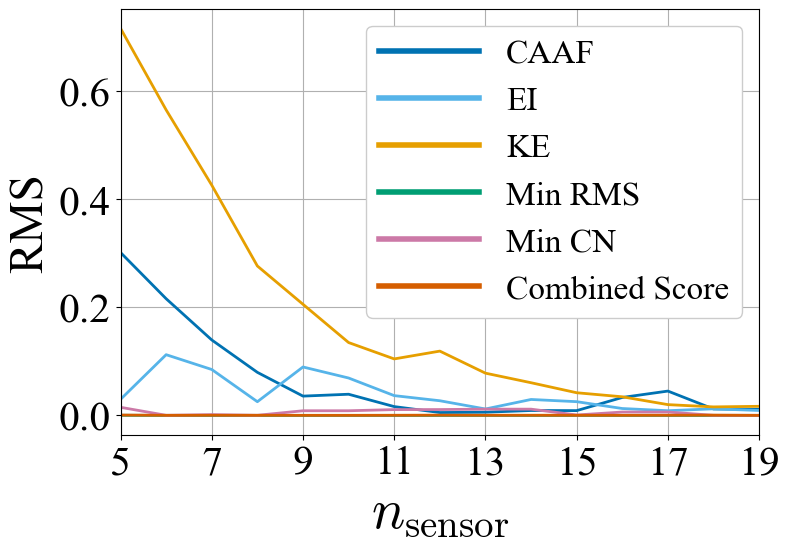

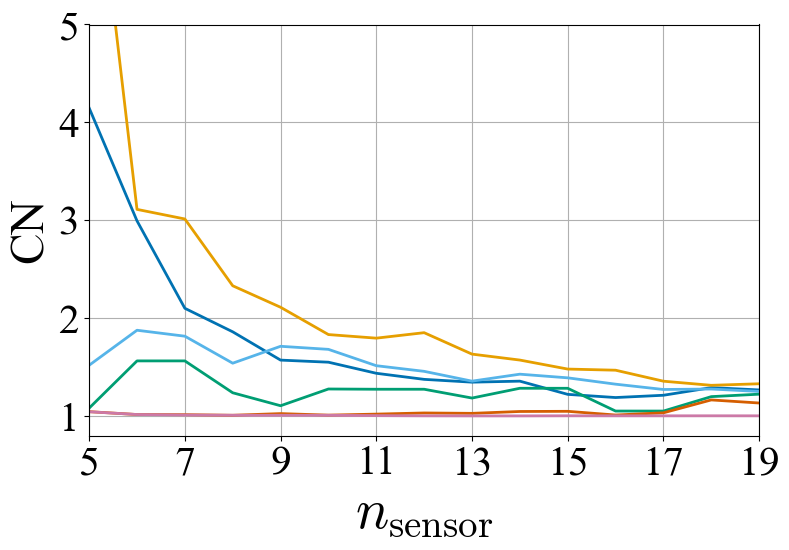

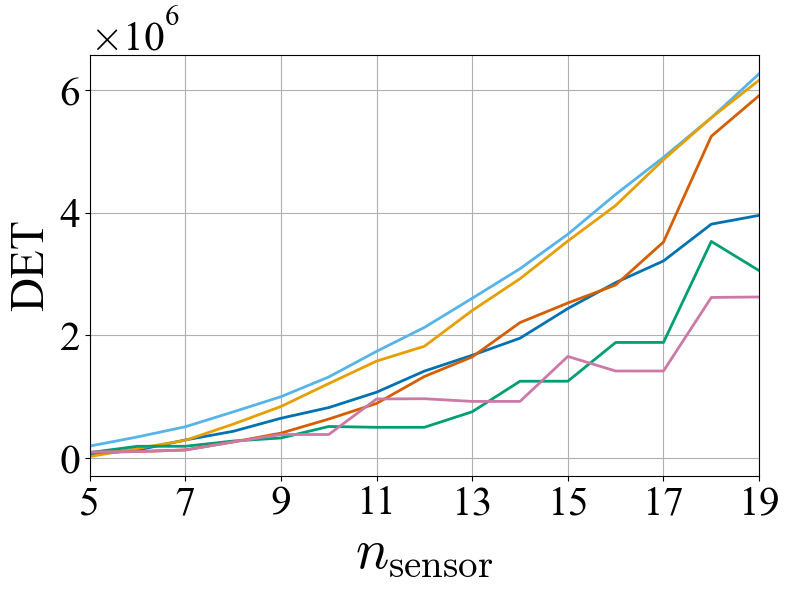

In [47]:
plt.rc('axes', labelsize=34, titlesize=20)
plt.rc('xtick',labelsize=30)
plt.rc('ytick',labelsize=30)

# attr_sensors = np.array([29,28,26,25,27,18,12,22,21,24,14,23,20,10,15])
# attr_sensors = np.array([29,28,27,10,20,26,14,18,24,25,21,12,16,7,15,22,23,4,1])
attr_sensors = [25,9,29,27,11,24,21,13,17,23,12,19,14,16,7,22,15,26,3]

# colors = [
#     [0.121569, 0.466667, 0.705882], # Python Blue
#     [0.839216, 0.152941, 0.156863], # Python Red
#     [0.172549, 0.627451, 0.172549], # Green
#     'm', # magenta
#     [0.090196, 0.745098, 0.811765],  # Teal
#     'y'
# ]
colors=['#0072B2', '#56B4E9', '#E69F00', '#009E73', '#D55E00', '#CC79A7']

n_sensor_max = 19
n_sensor_min = 5
n_sensors_list = np.arange(n_sensor_min,n_sensor_max+1)
RMS = np.zeros(n_sensor_max-n_sensor_min+1)
CN = np.zeros(n_sensor_max-n_sensor_min+1)
DET = np.zeros(n_sensor_max-n_sensor_min+1)

RMS_EI = np.zeros(n_sensor_max-n_sensor_min+1)
CN_EI = np.zeros(n_sensor_max-n_sensor_min+1)
DET_EI = np.zeros(n_sensor_max-n_sensor_min+1)

RMS_KE = np.zeros(n_sensor_max-n_sensor_min+1)
CN_KE = np.zeros(n_sensor_max-n_sensor_min+1)
DET_KE = np.zeros(n_sensor_max-n_sensor_min+1)

for n_sensors in n_sensors_list:
  sensors_test = attr_sensors[:n_sensors]
  results = process_modes(Xnx, sensors_test, verbose = False)
  RMS[n_sensors-n_sensor_min] = results['RMS']
  CN[n_sensors-n_sensor_min] = results['CN']
  DET[n_sensors-n_sensor_min] = results["DET"]

  EI_sensors = effective_independence(Xnx.T, n_sensors)
  results = process_modes(Xnx, EI_sensors, verbose = False)
  RMS_EI[n_sensors-n_sensor_min] = results['RMS']
  CN_EI[n_sensors-n_sensor_min] = results['CN']
  DET_EI[n_sensors-n_sensor_min] = results["DET"]

  KE_sensors = KE(Xnx.T, n_sensors)
  results = process_modes(Xnx, KE_sensors, verbose = False)
  RMS_KE[n_sensors-n_sensor_min] = results['RMS']
  CN_KE[n_sensors-n_sensor_min] = results['CN']
  DET_KE[n_sensors-n_sensor_min] = results["DET"]

plt.figure(figsize=(8, 5.6))
plt.grid(True)
plt.plot(n_sensors_list,RMS, color=colors[0],linewidth=2, label='CAAF')
plt.plot(n_sensors_list,RMS_EI, color=colors[1],linewidth=2, label='EI')
plt.plot(n_sensors_list,RMS_KE, color=colors[2],linewidth=2, label='KE')
plt.plot(n_sensors_list,min_RMS_metrics[0,:], color=colors[3],linewidth=2, label='Min RMS')
plt.plot(n_sensors_list,min_CN_metrics[0,:], color=colors[5],linewidth=2, label='Min CN')
plt.plot(n_sensors_list,combined_metrics[0,:], color=colors[4],linewidth=2, label='Combined Score')
plt.xlabel('$n_{\mathrm{sensor}}$',fontsize=40)
plt.ylabel('RMS')
plt.xlim([n_sensor_min,n_sensor_max])
plt.xticks(range(n_sensor_min, n_sensor_max+1, 2))
plt.tight_layout()
leg = plt.legend(handlelength=3, borderpad=0.4, fontsize=24, loc='upper right', framealpha=1)
for line in leg.get_lines():
    line.set_linewidth(4)
plt.savefig('SHM_6Config_RMS.pdf',format = 'pdf')
plt.savefig('SHM_6Config_RMS.png')
plt.show()

plt.figure(figsize=(8, 5.6))
plt.grid(True)
plt.plot(n_sensors_list,CN,color=colors[0],linewidth=2, label='CN')
plt.plot(n_sensors_list,CN_EI,color=colors[1],linewidth=2, label='CN_EI')
plt.plot(n_sensors_list,CN_KE,color=colors[2],linewidth=2, label='CN_KE')
plt.plot(n_sensors_list,min_RMS_metrics[1,:], color=colors[3],linewidth=2, label='CN_minRMS')
plt.plot(n_sensors_list,combined_metrics[1,:], color=colors[4],linewidth=2, label='CN_combined')
plt.plot(n_sensors_list,min_CN_metrics[1,:], color=colors[5],linewidth=2, label='CN_minCN')
plt.xlabel('$n_{\mathrm{sensor}}$',fontsize=40)
plt.ylabel('CN')
plt.ylim([0.8,5])
plt.xlim([n_sensor_min,n_sensor_max])
plt.xticks(range(n_sensor_min, n_sensor_max+1, 2))
plt.yticks(range(1, 6))
plt.tight_layout()
# plt.savefig('SHM_6Config_CN.pdf',format = 'pdf')
# plt.savefig('SHM_6Config_CN.png')
plt.show()

plt.figure(figsize=(8, 6))
plt.grid(True)
plt.plot(n_sensors_list,DET,color=colors[0],linewidth=2, label='DET')
plt.plot(n_sensors_list,DET_EI,color=colors[1],linewidth=2, label='DET_EI')
plt.plot(n_sensors_list,DET_KE,color=colors[2],linewidth=2, label='DET_KE')
plt.plot(n_sensors_list,min_RMS_metrics[2,:], color=colors[3],linewidth=2, label='DET_minRMS')
plt.plot(n_sensors_list,combined_metrics[2,:], color=colors[4],linewidth=2, label='DET_combined')
plt.plot(n_sensors_list,min_CN_metrics[2,:], color=colors[5],linewidth=2, label='DET_minCN')
plt.xlabel('$n_{\mathrm{sensor}}$',fontsize=40)
plt.ylabel('DET')
plt.xlim([n_sensor_min,n_sensor_max])
plt.xticks(range(n_sensor_min, n_sensor_max+1, 2))
# Force scientific notation if needed
ax = plt.gca()
ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0), useMathText=True)
# ax.yaxis.get_offset_text().set_fontsize(30) # Adjust font size of the offset text

# Adjust the offset text position (axes coordinates: 0-1)
offset_text = ax.yaxis.get_offset_text()
offset_text.set_position((0, 2))  # Slightly above the top
plt.tight_layout()
# plt.savefig('SHM_6Config_DET.pdf',format = 'pdf')
# plt.savefig('SHM_6Config_DET.png')
plt.show()

In [45]:
# Export .csv
data = {
    'n_sensors': n_sensors_list,
    'CAAF': DET,
    'KE': DET_KE,
    'Min RMS': min_RMS_metrics[2,:],
    'Min CN': min_CN_metrics[2,:],
    'EI (Max DET)': DET_EI,
    'Combined Score': combined_metrics[2,:]
}
df = pd.DataFrame(data)
df.to_csv('SHM_DET_6configs.csv', index=False)

L2 error = 0.023075292370655736


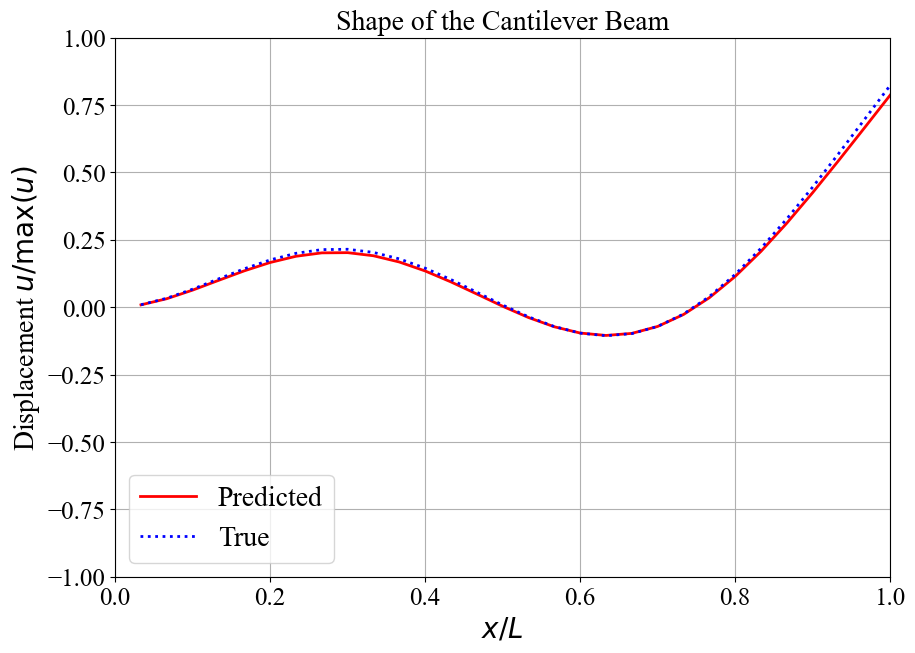

In [ ]:
test_i = 1000
# Plot results
with torch.no_grad():
  # test_output = model(torch.tensor(X_test).unsqueeze(0)).detach().numpy().squeeze(0)
  # test_output = model(torch.tensor(X_test))[test_i,:].detach().numpy()
  test_output = model(torch.tensor(X_test)).detach().numpy()


error = np.linalg.norm(test_output - y_test,2)/np.linalg.norm(y_test - np.mean(y_test),2) # L2 error norm
print('L2 error =', error)

# Plot results
# mode_coord_test = mode_coord[10000,:]  # for plotting only
plt.figure(figsize=(10, 7))
plt.grid(True)
# plt.plot(xl, Xnx[0, :], 'b-', linewidth=1.5, label='Mode #1')
# plt.plot(xl, Xnx[1, :], 'r-', linewidth=1.5, label='Mode #2')
# plt.plot(xl, Xnx[2, :], 'm-', linewidth=1.5, label='Mode #3')

# Superposed plot
superposed = test_output[test_i,:] @ Xnx
plt.plot(xl, superposed/disp_max, '-', color='r', linewidth=2, label='Predicted')

superposed_true = y_test[test_i,:] @ Xnx
plt.plot(xl, superposed_true/disp_max, ':', color='b', linewidth=2, label='True')

# Final plot formatting
plt.title('Shape of the Cantilever Beam')
plt.legend(loc='lower left',fontsize=20)
plt.ylim([-1,1])
plt.xlim([0,1])
plt.xlabel('$x/L$')
plt.ylabel('Displacement $u/\max(u)$')
plt.show()

# Brute Froce Search

In [ ]:
def compute_guyan_reduction_fast(M_global, sensor_nodes):
    """
    Optimized Guyan reduction using np.linalg.solve instead of inv.
    """
    total_dofs = M_global.shape[0]
    all_dofs = np.arange(total_dofs)

    # Identify master and slave DOFs
    master_dofs = np.array(sensor_nodes) # Assuming translational only based on your usage
    slave_dofs = np.setdiff1d(all_dofs, master_dofs)

    # Partition mass matrix
    M_mm = M_global[np.ix_(master_dofs, master_dofs)]
    M_ss = M_global[np.ix_(slave_dofs, slave_dofs)]
    M_ms = M_global[np.ix_(master_dofs, slave_dofs)]
    M_sm = M_ms.T # M_global is symmetric

    # Optimization: Solve linear system instead of inverting M_ss
    # We want: M_s = M_mm - M_ms @ (M_ss^-1 @ M_sm)
    # Let X = M_ss^-1 @ M_sm  =>  M_ss @ X = M_sm

    # Use standard solve (or Cholesky if M_ss is positive definite for more speed)
    X = np.linalg.solve(M_ss, M_sm)
    M_s = M_mm - M_ms @ X

    return M_s

def compute_metrics_fast(M_s, mode_shapes_s):
    """
    Vectorized computation of MMAC, RMS, CN, and DET.
    mode_shapes_s: (n_sensors, n_modes) at sensor locations
    """
    # Compute MMAC fully vectorized
    # Generalized mass matrix with respect to sensors
    # Q[i, j] = phi_i.T @ M_s @ phi_j
    Q = mode_shapes_s.T @ M_s @ mode_shapes_s

    # Get diagonal elements (modal masses)
    diag_Q = np.diag(Q)

    # Compute denominator matrix: outer product of diagonals
    denominator = np.outer(diag_Q, diag_Q)

    # MMAC calculation
    MMAC = (Q**2) / denominator

    # Compute RMS vectorized
    n_modes = MMAC.shape[0]
    # Create mask for off-diagonal elements
    mask = ~np.eye(n_modes, dtype=bool)
    off_diagonal_values = MMAC[mask]

    RMS = np.sqrt(np.mean(off_diagonal_values**2))

    # 3. Compute CN and DET
    CN = np.linalg.cond(mode_shapes_s)
    # Determinant of Fisher Information Matrix (Phi.T @ Phi)
    DET = np.linalg.det(mode_shapes_s.T @ mode_shapes_s)

    return RMS, CN, DET

In [ ]:
min_RMS_sensors = {}
min_CN_sensors = {}
combined_sensors = {}
min_RMS_metrics = np.zeros((3,15))
min_CN_metrics = np.zeros((3,15))
combined_metrics = np.zeros((3,15))

In [ ]:
import itertools
from tqdm import tqdm
import math

# --- GPU Setup ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Constants & Data Prep ---
L_total = 0.45
n_elements = 30
rho = 5219
A = 0.02 * 0.002
L_elem = L_total / n_elements

# Prepare matrices
M_global_np = assemble_global_mass_matrix(n_elements, rho, A, L_elem)
mode_shapes_full_np = Xnx.T
mode_shapes_norm_np = mass_normalize_modes(mode_shapes_full_np, M_global_np)

# Move to GPU
# Use float64 for stability
M_global = torch.tensor(M_global_np, device=device, dtype=torch.float64)
mode_shapes_norm = torch.tensor(mode_shapes_norm_np, device=device, dtype=torch.float64)

# Dimensions
n_total_dofs = M_global.shape[0]
all_dofs = torch.arange(n_total_dofs, device=device)

# Helper
def chunked_combinations(iterable, r, chunk_size):
    """Yields blocks of combinations as numpy arrays."""
    it = itertools.combinations(iterable, r)
    while True:
        chunk = list(itertools.islice(it, chunk_size))
        if not chunk:
            break
        yield np.array(chunk)

# Search Parameters
candidates = range(30) # 0 to 29
num_sensors_list = np.arange(11,20)
for num_sensors in num_sensors_list:
  # num_sensors = 5
  n_combs = math.comb(30, num_sensors)
  # n_combs = 155117520 # 30 choose 15
  batch_size = 50000 # Adjust based on GPU memory

  # Reference values for Combined Score
  REF_RMS = 0.01
  REF_CN_RANGE = 0.5
  MAX_DET = 3.7e6

  # Trackers
  best_RMS = float('inf')
  opt_RMS_sensors = None

  best_CN = float('inf')
  opt_CN_sensors = None

  best_DET = float('-inf')
  opt_DET_sensors = None

  best_combined = float('inf')
  opt_combined_sensors = None

  print(f"Starting GPU Brute Force Search (Total: {n_combs})...")

  # Main Loop
  with torch.no_grad():
      for batch_idx_np in tqdm(chunked_combinations(candidates, num_sensors, batch_size),
                              total=n_combs // batch_size + 1):

          current_batch_size = len(batch_idx_np)

          # Prepare Indices (B, n_s)
          master_idx = torch.tensor(batch_idx_np, device=device, dtype=torch.long)

          # Create Slave Indices (B, n_slave)
          # Create a mask of all DOFs, set master to False
          mask = torch.ones((current_batch_size, n_total_dofs), dtype=torch.bool, device=device)
          mask.scatter_(1, master_idx, False)
          # Get slave indices (the true values in mask)
          slave_idx = mask.nonzero(as_tuple=True)[1].view(current_batch_size, -1)

          # Gather submatrices
          # Expand indices for gather: (B, N, N)
          # M_mm: (B, 15, 15)
          M_mm = M_global[master_idx.unsqueeze(2), master_idx.unsqueeze(1)]
          # M_ss: (B, 16, 16)
          M_ss = M_global[slave_idx.unsqueeze(2), slave_idx.unsqueeze(1)]
          # M_sm: (B, 16, 15)
          M_sm = M_global[slave_idx.unsqueeze(2), master_idx.unsqueeze(1)]
          # M_ms is M_sm.mT

          # Guyan Reduction
          # Solve M_ss * X = M_sm
          X = torch.linalg.solve(M_ss, M_sm)
          M_s = M_mm - M_sm.mT @ X

          # Mode Shapes at Sensors (B, 15, 3)
          # mode_shapes_norm is (30, 3). Indices match 0-29.
          modes_s = mode_shapes_norm[master_idx]

          # Compute Metrics (Vectorized)

          # MMAC & RMS
          # Q = phi.T @ M_s @ phi  -> (B, 3, 3)
          Q = modes_s.mT @ M_s @ modes_s
          diag_Q = torch.diagonal(Q, dim1=1, dim2=2) # (B, 3)
          denominator = diag_Q.unsqueeze(2) * diag_Q.unsqueeze(1)
          MMAC = (Q ** 2) / denominator

          # RMS of off-diagonals
          # Create mask for off-diagonals (3x3)
          eye_mask = torch.eye(3, device=device, dtype=torch.bool).expand(current_batch_size, 3, 3)
          off_diag = torch.masked_select(MMAC, ~eye_mask).view(current_batch_size, -1)
          RMS = torch.sqrt(torch.mean(off_diag ** 2, dim=1))

          # CN & DET
          G = modes_s.mT @ modes_s # (B, 3, 3)
          L = torch.linalg.eigvalsh(G)

          # CN = sqrt(lambda_max / lambda_min)
          CN = torch.sqrt(L[:, -1] / L[:, 0])

          # DET = product(lambda) which is det(Phi.T @ Phi)
          DET = torch.prod(L, dim=1)

          # Combined Score
          Score = (RMS / REF_RMS) + ((CN - 1.0) / REF_CN_RANGE) + (1.0 - DET / MAX_DET)

          # Update Bests (transfer minimal data to CPU)

          # RMS
          min_rms_val, min_rms_arg = torch.min(RMS, dim=0)
          if min_rms_val.item() < best_RMS:
              best_RMS = min_rms_val.item()
              opt_RMS_sensors = batch_idx_np[min_rms_arg.item()]

          # CN
          min_cn_val, min_cn_arg = torch.min(CN, dim=0)
          if min_cn_val.item() < best_CN:
              best_CN = min_cn_val.item()
              opt_CN_sensors = batch_idx_np[min_cn_arg.item()]

          # DET
          max_det_val, max_det_arg = torch.max(DET, dim=0)
          if max_det_val.item() > best_DET:
              best_DET = max_det_val.item()
              opt_DET_sensors = batch_idx_np[max_det_arg.item()]

          # Combined
          min_comb_val, min_comb_arg = torch.min(Score, dim=0)
          if min_comb_val.item() < best_combined:
              best_combined = min_comb_val.item()
              opt_combined_sensors = batch_idx_np[min_comb_arg.item()]

  # --- Results ---
  print("\n--- Results ---")
  print(f"Optimal RMS sensors: {opt_RMS_sensors} | Min RMS: {best_RMS}")
  print(f"Optimal CN sensors:  {opt_CN_sensors} | Min CN:  {best_CN}")
  print(f"Optimal DET sensors: {opt_DET_sensors} | Max DET: {best_DET}")
  print("-"*30)
  print(f"Optimal Combined sensors: {opt_combined_sensors}")
  print(f"Min Combined Score: {best_combined}")

  min_RMS_sensors[num_sensors] = opt_RMS_sensors
  min_CN_sensors[num_sensors] = opt_CN_sensors
  combined_sensors[num_sensors] = opt_combined_sensors
  res_modes = process_modes(Xnx, opt_RMS_sensors, verbose=False)
  min_RMS_metrics[0,num_sensors-5] = res_modes["RMS"]
  min_RMS_metrics[1,num_sensors-5] = res_modes["CN"]
  min_RMS_metrics[2,num_sensors-5] = res_modes["DET"]
  res_modes = process_modes(Xnx, opt_CN_sensors, verbose=False)
  min_CN_metrics[0,num_sensors-5] = res_modes["RMS"]
  min_CN_metrics[1,num_sensors-5] = res_modes["CN"]
  min_CN_metrics[2,num_sensors-5] = res_modes["DET"]
  res_modes = process_modes(Xnx, opt_combined_sensors, verbose=False)
  combined_metrics[0,num_sensors-5] = res_modes["RMS"]
  combined_metrics[1,num_sensors-5] = res_modes["CN"]
  combined_metrics[2,num_sensors-5] = res_modes["DET"]

  # # Plot best combined
  # if opt_combined_sensors is not None:
  #     # Move back to CPU/Numpy for plotting functions
  #     plot_cantilever_sensors(6, 30, opt_combined_sensors)
  #     res_modes = process_modes(Xnx, opt_combined_sensors, verbose=True)

Using device: cuda
Starting GPU Brute Force Search (Total: 54627300)...


100%|██████████████████████████████████████████████████████████████████████████████| 1093/1093 [01:32<00:00, 11.86it/s]



--- Results ---
Optimal RMS sensors: [ 1  2  5  6  7 11 17 19 20 26 28] | Min RMS: 5.083196323236117e-07
Optimal CN sensors:  [ 8  9 10 12 16 17 19 22 23 26 28] | Min CN:  1.0053024741662522
Optimal DET sensors: [ 8  9 10 11 18 19 20 21 27 28 29] | Max DET: 1739021.317816434
------------------------------
Optimal Combined sensors: [ 6  8 10 12 14 17 19 21 23 26 28]
Min Combined Score: 0.8185598346538403
Starting GPU Brute Force Search (Total: 86493225)...


100%|██████████████████████████████████████████████████████████████████████████████| 1730/1730 [02:26<00:00, 11.82it/s]



--- Results ---
Optimal RMS sensors: [ 0  1  2  5  6  7 11 17 19 20 26 28] | Min RMS: 2.6538442151548414e-07
Optimal CN sensors:  [ 1  8  9 10 12 16 17 19 22 23 26 28] | Min CN:  1.0032210309752299
Optimal DET sensors: [ 8  9 10 11 12 18 19 20 21 27 28 29] | Max DET: 2128865.820061628
------------------------------
Optimal Combined sensors: [ 8  9 10 12 13 17 18 21 22 23 27 28]
Min Combined Score: 0.7446278194952574
Starting GPU Brute Force Search (Total: 119759850)...


...


--- Results ---
Optimal RMS sensors: [ 0  2  4  6  9 10 11 13 15 16 17 20 22 23 24 27 28] | Min RMS: 2.0080101597411002e-07
Optimal CN sensors:  [ 0  1  2  3  5  7 10 11 12 15 17 19 20 22 25 26 28] | Min CN:  1.0032610565389017
Optimal DET sensors: [ 7  8  9 10 11 12 16 17 18 19 20 21 22 26 27 28 29] | Max DET: 4908744.524089142
------------------------------
Optimal Combined sensors: [ 7  8  9 10 11 12 15 16 18 19 20 21 22 25 26 27 28]
Min Combined Score: 0.14012290425225826
Starting GPU Brute Force Search (Total: 86493225)...


100%|██████████████████████████████████████████████████████████████████████████████| 1730/1730 [02:43<00:00, 10.60it/s]



--- Results ---
Optimal RMS sensors: [ 3  4  7  8 10 11 12 14 16 17 18 19 21 24 25 26 27 29] | Min RMS: 2.447541339792022e-07
Optimal CN sensors:  [ 2  3  5  7  8 10 11 13 14 16 18 19 20 22 24 25 27 28] | Min CN:  1.0036124205192998
Optimal DET sensors: [ 7  8  9 10 11 12 13 17 18 19 20 21 22 23 26 27 28 29] | Max DET: 5568666.063347506
------------------------------
Optimal Combined sensors: [ 7  8  9 10 11 12 13 14 18 19 20 21 22 23 24 27 28 29]
Min Combined Score: -0.04415130922126892
Starting GPU Brute Force Search (Total: 54627300)...


100%|██████████████████████████████████████████████████████████████████████████████| 1093/1093 [01:43<00:00, 10.54it/s]


--- Results ---
Optimal RMS sensors: [ 1  2  4  5  6  7  8 10 14 15 16 17 20 21 23 25 26 27 29] | Min RMS: 2.0998645129685011e-07
Optimal CN sensors:  [ 1  2  3  5  7  8 10 11 13 14 16 18 19 20 22 24 25 27 28] | Min CN:  1.0032471000858625
Optimal DET sensors: [ 7  8  9 10 11 12 13 16 17 18 19 20 21 22 25 26 27 28 29] | Max DET: 6265413.307441261
------------------------------
Optimal Combined sensors: [ 7  8  9 10 11 12 13 14 16 18 19 20 21 22 23 24 27 28 29]
Min Combined Score: -0.32460478531970516


In [ ]:
# np.save('min_RMS_sensors.npy', min_RMS_sensors)
# np.save('min_CN_sensors.npy', min_CN_sensors)
# np.save('combined_sensors.npy', combined_sensors)
# np.save('min_RMS_metrics.npy', min_RMS_metrics)
# np.save('min_CN_metrics.npy', min_CN_metrics)
# np.save('combined_metrics.npy', combined_metrics)

min_RMS_sensors = np.load('min_RMS_sensors.npy', allow_pickle=True)
min_CN_sensors = np.load('min_CN_sensors.npy', allow_pickle=True)
combined_sensors = np.load('combined_sensors.npy', allow_pickle=True)
min_RMS_metrics = np.load('min_RMS_metrics.npy', allow_pickle=True)
min_CN_metrics = np.load('min_CN_metrics.npy', allow_pickle=True)
combined_metrics = np.load('combined_metrics.npy', allow_pickle=True)

The combined optimization score $S$ is defined as:

$$
S = \frac{RMS}{RMS_{\text{ref}}} + \frac{CN - 1}{CN_{\text{range}}} + \left( 1 - \frac{DET}{DET_{\text{max}}} \right)
$$

Where:
- $RMS$: Root Mean Square of the off-diagonal elements of the MMAC matrix.
- $CN$: Condition Number of the mode shape matrix.
- $DET$: Determinant of the Fisher Information Matrix (FIM).
- $RMS_{\text{ref}}$, $CN_{\text{range}}$, $DET_{\text{max}}$: Reference normalization constants.

# Other Method

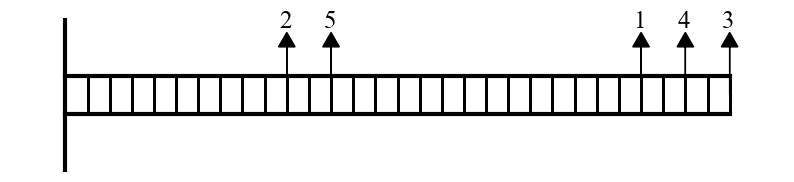

RMS = 0.3008548
CN = 4.1475
DET = 57506.5


In [ ]:
# sensor_nodes = np.array([25,9,29,27,11,24,21,13,17,23,12,19,14,16,7]) # <Selected sensors>, 2nd BEST SO FAR, 19 clusters and w/ batchnorm, 30k attr, converged
# sensor_nodes = np.array([25,10,28,27,21,24,11,13,17,23,12,19,14,16,7]) # BEST SO FAR, 19 clusters and w/ batchnorm, 10k attr
# sensor_nodes = np.array([27,16,23,21,14,17,28,19,12,26,24,3,25,15,10]) # testing: best attr
# sensor_nodes = np.array([5,6,7,8,9,18,19,20,21,22,23,24,25,26,29])  # EI given by Liu et al.
# sensor_nodes = np.array([10,11,18,21,27])  # Exhaustive Search given by Friswell.
# sensor_nodes = np.array([28,26,25,24,23,22,21,20,19,17,12,9,8,6,4])  # Min-RMS given by Liu.
# sensor_nodes = np.array([26,28,18,12,15]) # 11 clusters best attr
sensors = [25,9,29,27,11] # CAAF
# sensors = [29,28, 27, 26,  9] # KE
# sensors = [10, 12, 18, 22, 27] # RMS
# sensors = [10, 11, 18, 21, 27] # CN
# sensors = [ 9 ,10, 19, 20 ,29] # DET
# sensors = [ 9, 12, 18, 22, 27] # Combined
# sensor_nodes = attr_sensors[:5]

plot_cantilever_sensors(6,30, sensors[:5])
results = process_modes(Xnx, sensors[:5], verbose = True)

In [ ]:
# Liu Beam parameters
# L_total = 6.0  # Beam length in meters
# n_elements = 30  # Number of finite elements
# L = L_total / n_elements  # Element length
# rho = 2500  # kg/m³ (density)
# A = 0.25 * 0.2  # Cross-sectional area

# Friswell
L_total = 0.45  # Beam length in meters
n_elements = 30  # Number of finite elements
L = L_total / n_elements  # Element length
rho = 5219  # kg/m³ (density)
A = 0.02 * 0.002  # Cross-sectional area

Optimal Sensor Nodes Selected by EI Method: [8, 9, 10, 11, 12, 17, 18, 19, 20, 21, 22, 26, 27, 28, 29]


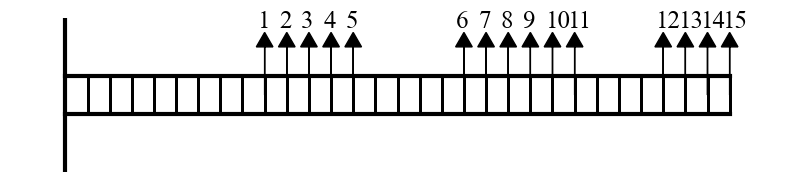

RMS = 0.02529781560788308
CN = 1.3912213656316834
DET = 3648956.2370236106


In [ ]:
# EI Method
num_sensors = 15  # Number of sensors to select

# Apply the EI method
EI_sensors = effective_independence(Xnx.T, num_sensors)

# Print the selected sensor locations
print("Optimal Sensor Nodes Selected by EI Method:", EI_sensors)
plot_cantilever_sensors(6,30, EI_sensors)
sensor_nodes = EI_sensors
results = process_modes(Xnx, sensor_nodes[:15], verbose = True)

Optimal Sensor Nodes Selected by EI_mass Method: [8, 9, 10, 11, 12, 17, 18, 19, 20, 21, 22, 26, 27, 28, 29]


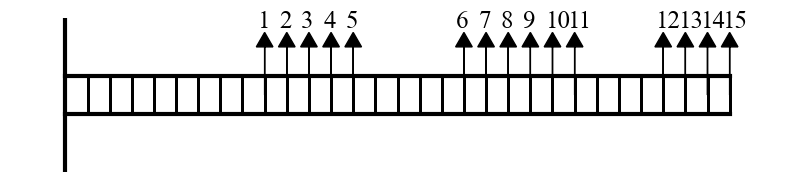

RMS = 0.02529781560788308
CN = 1.3912213656316834
DET = 3648956.2370236106


In [ ]:
# EI_mass Method
num_sensors = 15  # Number of sensors to select

# Calculate element length and element mass
L_element = L_total / n_elements
element_mass = rho * A * L_element  # Mass per element in kg

# Create diagonal mass matrix (30 × 30)
mass_matrix = np.diag([element_mass] * n_elements)

# Apply the EI method
EI_mass_sensors = EI_mass(Xnx.T, mass_matrix, num_sensors)

# Print the selected sensor locations
print("Optimal Sensor Nodes Selected by EI_mass Method:", EI_mass_sensors)
plot_cantilever_sensors(6,30, EI_mass_sensors)
sensor_nodes = EI_mass_sensors
results = process_modes(Xnx, sensor_nodes[:15], verbose = True)

Optimal Sensor Nodes Selected by EI_dapr Method: [7, 8, 9, 10, 11, 17, 18, 19, 20, 21, 22, 26, 27, 28, 29]


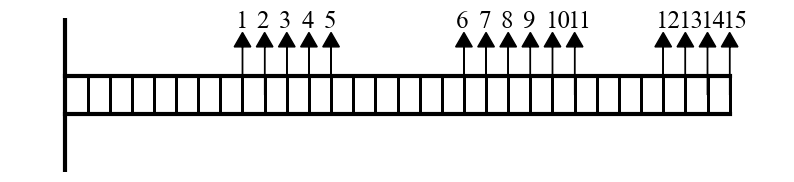

RMS = 0.025490205341876643
CN = 1.432089045718464
DET = 3638875.952881421


In [ ]:
# EI_dapr Method
num_sensors = 15  # Number of sensors to select

# Calculate element length and element mass
L_element = L_total / n_elements
element_mass = rho * A * L_element  # Mass per element in kg

# Create diagonal mass matrix (30 × 30)
mass_matrix = np.diag([element_mass] * n_elements)

# Apply the EI method
EI_dapr_sensors = EI_dapr(Xnx.T, mass_matrix, num_sensors)

# Print the selected sensor locations
print("Optimal Sensor Nodes Selected by EI_dapr Method:", EI_dapr_sensors)
plot_cantilever_sensors(6,30, EI_dapr_sensors)
sensor_nodes = EI_dapr_sensors
results = process_modes(Xnx, sensor_nodes[:15], verbose = True)

Optimal Sensor Nodes Selected by KE Method: [29 28 27 26  9 19 20  8 10 18 21 25 11 17  7]


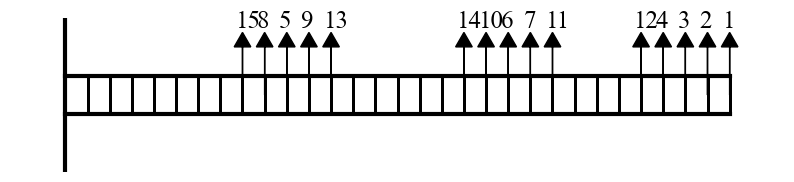

RMS = 0.04179862115613258
CN = 1.4808029922676302
DET = 3537650.131287547


In [ ]:
# WAKE Method
num_sensors = 15  # Number of sensors to select
WAKE_sensors = WAKE(Xnx.T, num_sensors)

# Print the selected sensor locations
print("Optimal Sensor Nodes Selected by WAKE Method:", WAKE_sensors)
plot_cantilever_sensors(6,30, WAKE_sensors)
sensor_nodes = WAKE_sensors
results = process_modes(Xnx, sensor_nodes[:15], verbose = True)

Optimal Sensor Nodes Selected by KE Method: [29 28 27 26  9]


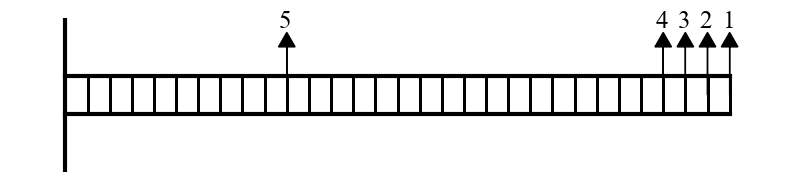

RMS = 0.7149177433437096
CN = 7.292817913745113
DET = 22923.948875703507


In [ ]:
# KE Method
num_sensors = 5  # Number of sensors to select

# Apply the EI method
KE_sensors = KE(Xnx.T, num_sensors)

# Print the selected sensor locations
print("Optimal Sensor Nodes Selected by KE Method:", KE_sensors)
plot_cantilever_sensors(6,30, KE_sensors)
sensor_nodes = KE_sensors
results = process_modes(Xnx, sensor_nodes[:15], verbose = True)

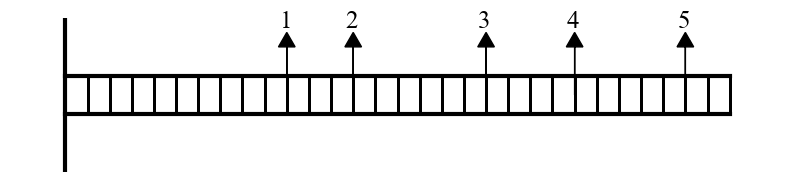

In [ ]:
# Plot and save sensors
L=6
n_candidate=30
# sensors = np.array([25,9,29,27,11,24,21,13,17,23,12,19,14,16,7]) # <Selected sensors>, 2nd BEST SO FAR, 19 clusters and w/ batchnorm, 30k attr, converged
# sensors = [25,9,29,27,11] # CAAF
# sensors = [29,28, 27, 26,  9] # KE
# sensors = [10, 12, 18, 22, 27] # RMS
# sensors = [10, 11, 18, 21, 27] # CN
# sensors = [ 9 ,10, 19, 20 ,29] # DET
sensors = [ 9, 12, 18, 22, 27] # Combined
# sensors = EI_sensors

x_candidate = np.linspace(L/30, L, n_candidate)
# Plot the beam
plt.figure(figsize=(10, 2))
plt.plot([0, L], [0.2, 0.2], 'k-', linewidth=3)  # Beam (horizontal line)
plt.plot([0, L], [-0.2, -0.2], 'k-', linewidth=3)  # Beam (horizontal line)

# Fixed support (like a wall at x = 0)
plt.plot([0, 0], [-0.8, 0.8], 'k', linewidth=3)  # Thick vertical wall

# Plot arrows (loads) at x_list
rank = 1
for i in sensors:
  # plt.scatter(x_candidate[i], 0, marker='x', s=100, color='black', linewidth=2)
  plt.arrow(x_candidate[i], 0.0, 0, 0.5, head_width=0.15, head_length=0.15, fc='k', ec='k')
  annotation = plt.annotate(str(rank), (x_candidate[i]-0.07, 0.7), fontsize=18, color='black')
  plt.plot([x_candidate, x_candidate], [-0.2, 0.2], 'k', linewidth=2)

  rank += 1

# Formatting
plt.xlim(-0.5, L + 0.5)
plt.ylim(-0.8, 0.8)
plt.axis('off')
plt.savefig('SHM_combined_5.eps',format = 'eps')
plt.show()